# Initial plots

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np 

df = pd.read_csv('gpt2_results/last-pooling/summary_results.csv')
ax = df.plot(
    x='model_layer',
    y=['uuas', 'spearmanr'],
    marker='o',
    color=['#1f77b4', '#3399cc'],
    linewidth=2
)
ax.yaxis.set_major_locator(plt.MaxNLocator(10)) 
plt.show()

KeyboardInterrupt: 

In [ ]:
from conllu import parse_incr
input_path = '../data/en_ewt-ud-dev_cleaned.conllu'
with open(input_path, "r", encoding="utf-8") as fin:
                sentences = list(parse_incr(fin))

In [ ]:
sentences[0][0]
sent = sentences[0].metadata["text"]
sent2 = " ".join([tok["form"] for tok in sentences[0]])
word_list = [tok["form"] for tok in sentences[0]]
word_list


sent2 = " ".join([tok["form"] for tok in sentences[0]])
word_list2 = [tok["form"] for tok in sentences[0]]
word_list2

['From', 'the', 'AP', 'comes', 'this', 'story', ':']

In [ ]:
df_sent = pd.read_pickle('gpt2_results/gpt2-parse-distance-2026-1-19-15-9-40-208149/dev_by_sentence.pkl')
df_sent

FileNotFoundError: [Errno 2] No such file or directory: 'gpt2_results/gpt2-parse-distance-2026-1-19-15-9-40-208149/dev_by_sentence.pkl'

NameError: name 'sns' is not defined

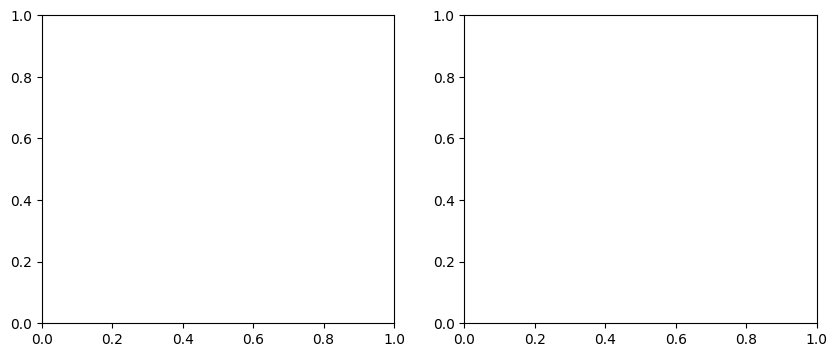

In [ ]:
idx = 0

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 4),
    squeeze=False
)

# Set heatmaps
sns.heatmap(df_sent['label'][idx], cmap="Blues", ax=ax[0, 0], square=True)
sns.heatmap(df_sent['prediction'][idx], cmap="Blues", ax=ax[0, 1], square=True)

# Set axis labels to the sentence tokens
sentence_tokens = df_sent["sentence"][idx]
ax[0, 0].set_xticklabels(sentence_tokens, rotation=90)
ax[0, 0].set_yticklabels(sentence_tokens, rotation=0)
ax[0, 1].set_xticklabels(sentence_tokens, rotation=90)
ax[0, 1].set_yticklabels(sentence_tokens, rotation=0)

ax[0, 0].set_title("Label")
ax[0, 1].set_title("Prediction")

plt.tight_layout()
plt.show()

In [ ]:
print(df_sent['gold_edges'][idx])
print(df_sent['pred_edges'][idx])

[(0, 2), (1, 2), (2, 3), (3, 5), (4, 5)]
[(2, 3), (0, 3), (4, 5), (1, 3), (3, 5)]


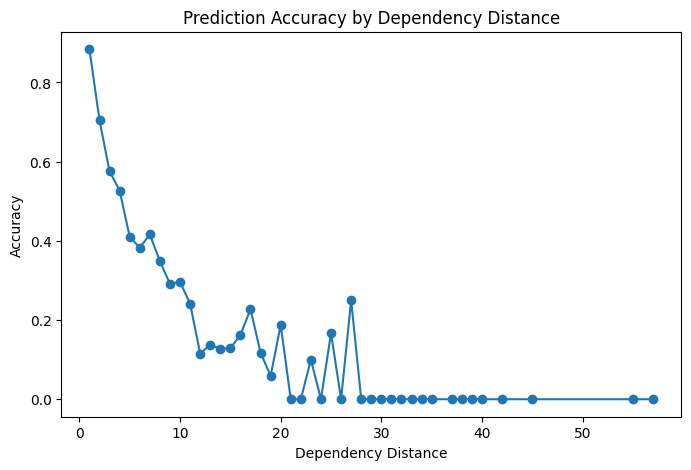

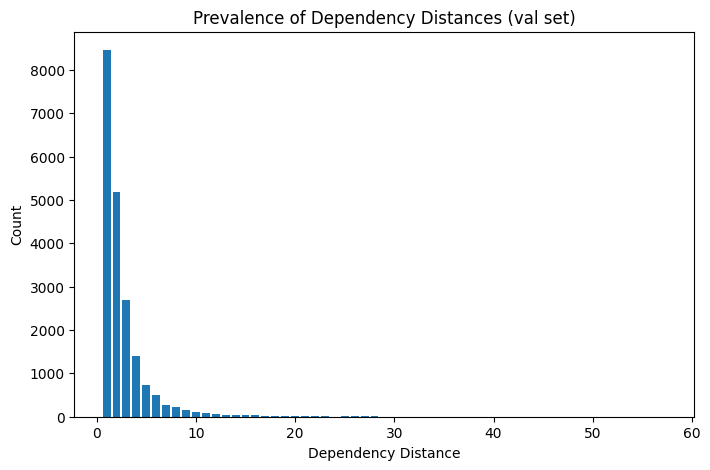

In [ ]:
dist_dict = {}
for i in range(len(df_sent)):
    
    gold_edges = df_sent['gold_edges'][i]
    pred_edges = df_sent['pred_edges'][i]
    
    if len(gold_edges) == 0:
        continue
    
    for i in set([tuple(sorted(x)) for x in gold_edges]).intersection(set([tuple(sorted(x)) for x in pred_edges])):
        dist = abs(i[0]-i[1])
        dist_dict[dist] = dist_dict.get(dist, []) + [1]
    for i in set([tuple(sorted(x)) for x in gold_edges]) - set([tuple(sorted(x)) for x in pred_edges]):
        dist = abs(i[0]-i[1])
        dist_dict[dist] = dist_dict.get(dist, []) + [0]

distances = sorted(dist_dict.keys())

# bin distances for better visualization

accuracies = [np.mean(dist_dict[d]) for d in distances]
plt.figure(figsize=(8, 5))
plt.plot(distances, accuracies, marker='o')
plt.xlabel('Dependency Distance')
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy by Dependency Distance')
plt.show()

counts = [len(dist_dict[d]) for d in distances]
plt.figure(figsize=(8, 5))
plt.bar(distances, counts)
plt.xlabel('Dependency Distance')
plt.ylabel('Count')
plt.title('Prevalence of Dependency Distances (val set)')
plt.show()
    

In [ ]:
import transformer_lens
model = transformer_lens.HookedTransformer.from_pretrained("gpt2")
tokenizer = model.tokenizer

/home/c13745859/anaconda3/envs/probing_lms_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer


In [ ]:
cache.keys()

dict_keys(['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_mid', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'blocks.1.hook_mlp_out', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'block

In [ ]:
text = "The quick brown fox jumps over the lazily sleeping dog lala lala lllpkn."
word_list = text.split()
print(word_list)
print(len(word_list))

['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazily', 'sleeping', 'dog', 'lala', 'lala', 'lllpkn.']
13


In [ ]:
import torch
import re

In [ ]:
layer_names = [f"blocks.{i}.hook_resid_post" for i in range(model.cfg.n_layers)]
pooling = "mean"

In [ ]:
encoding = tokenizer(
    text,
    return_offsets_mapping=True,
    return_tensors="pt",
    add_special_tokens=False,
)
offsets = encoding["offset_mapping"][0].tolist()
_, cache = model.run_with_cache([text], prepend_bos=False)
activations = {layer: cache[layer][0] for layer in layer_names}
assert activations[layer_names[0]].shape[0] == len(offsets)
word_spans = []
cursor = 0
for word in word_list:
    match = re.search(re.escape(word), text[cursor:])
    if match is None:
        raise ValueError(f"Word '{word}' not found after position {cursor}")
    start = cursor + match.start()
    end = start + len(word)
    word_spans.append((start, end))
    cursor = end
word_embeddings = []
token_idxs_list = []
for (ws, we) in word_spans:
    token_idxs = [
        i for i, (ts, te) in enumerate(offsets)
        if ts < we and te > ws
    ]
    if not token_idxs:
        raise ValueError(
            f"No tokens aligned to '{text[ws:we]}' at span {(ws, we)}"
        )
    token_embs = {layer: activations[layer][token_idxs] for layer in layer_names}
    if pooling == "last":
        word_emb = {layer: token_embs[layer][-1] for layer in layer_names}
        token_idxs = token_idxs[-1]
    elif pooling == "first":
        word_emb = {layer: token_embs[layer][0] for layer in layer_names}
        token_idxs = token_idxs[0]
    elif pooling == "mean":
        word_emb = {layer: token_embs[layer].mean(dim=0) for layer in layer_names}
        token_idxs = np.mean(token_idxs)
    word_embeddings.append(word_emb)
    token_idxs_list.append(token_idxs)
stacked = torch.stack(
    [torch.stack([we[layer] for we in word_embeddings]) for layer in layer_names]
)
        

In [ ]:
print(token_idxs_list)

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.5, 9.0, 10.0, 11.5, 13.5, 16.5]


In [ ]:
print(offsets)
print(len(offsets))
print(word_spans)
print(len(word_embeddings))

[[0, 3], [3, 9], [9, 15], [15, 19], [19, 25], [25, 30], [30, 34], [34, 38], [38, 41], [41, 50], [50, 54], [54, 56]]
12
[(0, 3), (4, 9), (10, 15), (16, 19), (20, 25), (26, 30), (31, 34), (35, 41), (42, 50), (51, 54), (55, 56)]
11


In [ ]:
def decay_function(d, E, alpha=0.5, n=10):
    if d < E:
        d = 1
    elif d >= E and d < n:
        exponent = 1 / (np.e * alpha)
        d =  1 - ((d-E+1)/(n-E))** exponent
    else:
        d = 0
    return d

In [ ]:
values = [decay_function(d, E = 5, alpha=1, n=50) for d in range(20)]
print(values)

[1, 1, 1, 1, 1, 0.7534998974475001, 0.68190279666056, 0.6307332493600343, 0.5895099850888605, 0.5543911588828021, 0.5234780048831902, 0.4956740689138046, 0.4702812518538878, 0.446824030837241, 0.4249619993057807, 0.4044419992471959, 0.38506997600902104, 0.36669347555098797, 0.3491902575743939, 0.33246060706712]


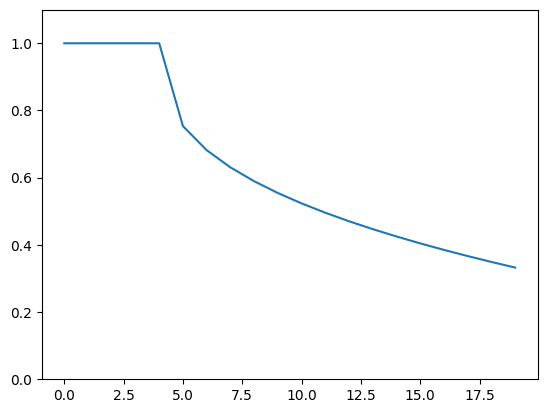

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(20), values)
plt.ylim(0, 1.1)
plt.show()

# Plot fine tuning

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df_sent_1 = pd.read_pickle('gpt2_results/fleet_test/gpt2-parse-distance-2026-2-4-17-12-9-224529/dev_by_sentence.pkl')
df_sent_2 = pd.read_pickle('gpt2_results/fleet_test/gpt2-parse-distance-2026-2-4-16-30-9-237167/dev_by_sentence.pkl')
df_tok = pd.read_pickle('../embeddings/gpt2_dev_embeddings_mean_toks.pkl')

In [ ]:
def plot_distance_accuracy(
        dfs, labels, df_tok, plot_delta = False, add_hist = False, plot_counts = False,
        E = 10, alpha = 1, n = 50
        ):
    df_sent_dicts = []
    for df_sent in dfs:
        dist_dict = {}
        for i in range(len(df_sent)):
        
            gold_edges = df_sent['gold_edges'][i]
            pred_edges = df_sent['pred_edges'][i]
            
            if len(gold_edges) == 0:
                continue
            
            for j in set([tuple(sorted(x)) for x in gold_edges]).intersection(set([tuple(sorted(x)) for x in pred_edges])):
                a_toks = df_tok["token_idxs"][i][j[0]]
                b_toks = df_tok["token_idxs"][i][j[1]]
                dist = abs(a_toks - b_toks)
                dist_dict[np.round(dist)] = dist_dict.get(np.round(dist), []) + [1]
            for j in set([tuple(sorted(x)) for x in gold_edges]) - set([tuple(sorted(x)) for x in pred_edges]):
                a_toks = df_tok["token_idxs"][i][j[0]]
                b_toks = df_tok["token_idxs"][i][j[1]]
                dist = abs(a_toks - b_toks)
                dist_dict[np.round(dist)] = dist_dict.get(np.round(dist), []) + [0]
        
        binned_dict = {}
        labels = []
        for key in sorted(dist_dict.keys()):
            if key <= 10:
                binned_dict[key] = dist_dict[key]
                labels.append(str(int(key)))
            elif key <= 20 and key % 2 == 0:
                binned_dict[key] = dist_dict[key] + dist_dict[key-1]
                labels.append(str(int(key-1)) + "-" + str(int(key)))
            elif key <= 50 and key % 10 == 0:
                binned_dict[key] = [item for i in range(0, 10) if (key - i) in dist_dict for item in dist_dict[key - i]]
                labels.append(str(int(key-9)) + "-" + str(int(key)))

        df_sent_dicts.append(binned_dict)

    accuracies_1 = [np.mean(df_sent_dicts[0][d]) for d in df_sent_dicts[0].keys()]
    accuracies_2 = [np.mean(df_sent_dicts[1][d]) for d in df_sent_dicts[1].keys()]

    def decay_function(d, E, alpha, n):
        if d < E:
            d = 1
        elif d >= E and d < n:
            exponent = 1 / (np.e * alpha)
            d =  1 - ((d-E+1)/(n-E))** exponent
        else:
            d = 0
        return d
    if plot_delta:
        deltas = [a - b for a, b in zip(accuracies_1, accuracies_2)]
        
        plt.figure(figsize=(12, 6))
        plt.bar(list(df_sent_dicts[0].keys()), deltas, color = "lightblue")
        plt.axhline(y=0, color='gray', linestyle='--')
        plt.ylim([-0.2, 0.2])

        plt.xticks(list(df_sent_dicts[0].keys()), labels, fontsize=5)
        plt.xlabel('Dependency Distance')
        plt.ylabel('Accuracy Delta')
        plt.title('Accuracy Delta by Dependency Distance')
    else:
        plt.figure(figsize=(12, 6))
        plt.plot(list(df_sent_dicts[0].keys()), accuracies_1, marker='o', color = "lightblue", label = labels[0])
        plt.plot(list(df_sent_dicts[1].keys()), accuracies_2, marker='o', color = "royalblue", label = labels[1])

        # add decay func
        plt.plot(
            list(df_sent_dicts[0].keys()),
            [decay_function(d, E=E, alpha=alpha, n=n) for d in list(df_sent_dicts[0].keys())],
            linestyle='--',
            color='gray',
            label='Decay Function'
        )

        plt.xticks(list(df_sent_dicts[0].keys()), labels, fontsize=5)

        # plt.xscale('log')
        plt.xlabel('Dependency Distance')
        plt.ylabel('Accuracy')
        plt.title('Prediction Accuracy by Dependency Distance')

    plt.legend()
    plt.show()

    if plot_counts:
        counts = [len(df_sent_dicts[0][d]) for d in df_sent_dicts[0].keys()]
        # counts = counts / np.sum(counts)

        x = np.arange(len(df_sent_dicts[0].keys()))
        width = 0.5 

        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.bar(x, counts, width)

        ax.set_xlabel('Dependency Distance')
        ax.set_ylabel('Count')
        ax.set_title('Prevalence of Dependency Distances (val set)')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=5)

        plt.show()



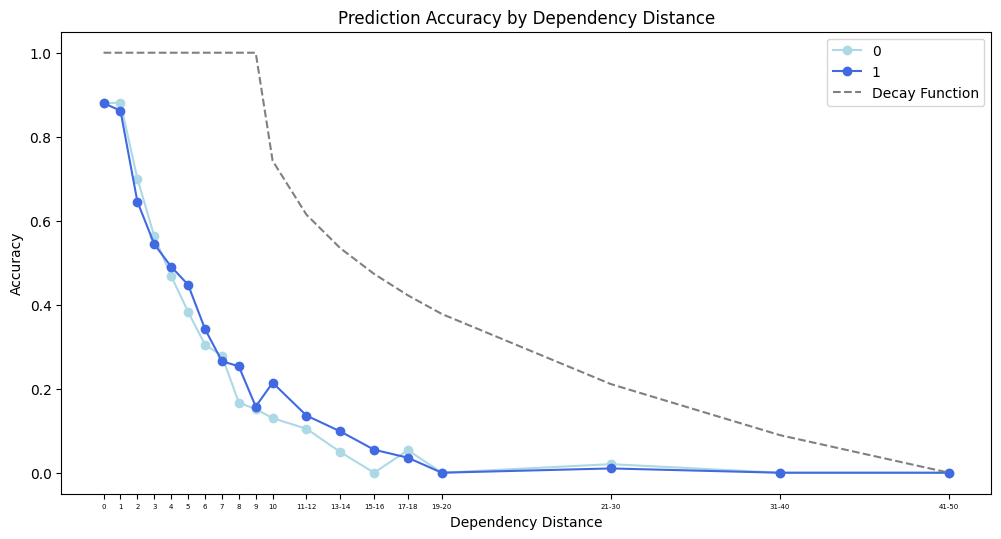

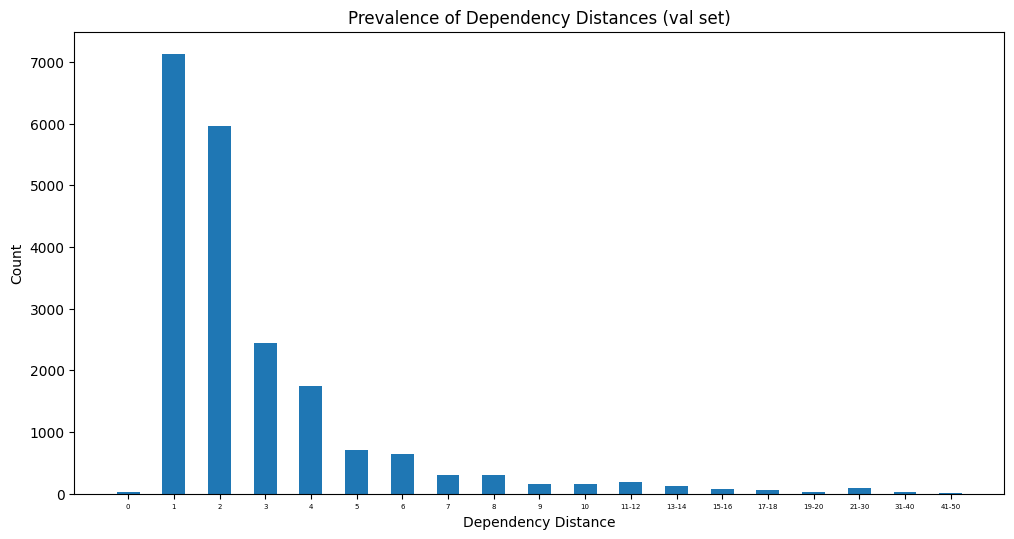

In [ ]:
plot_distance_accuracy(dfs = [df_sent_1, df_sent_2], labels = ["nomask", "mask"], df_tok = df_tok, plot_delta = False, plot_counts = True)

/tmp/ipykernel_29723/297943237.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


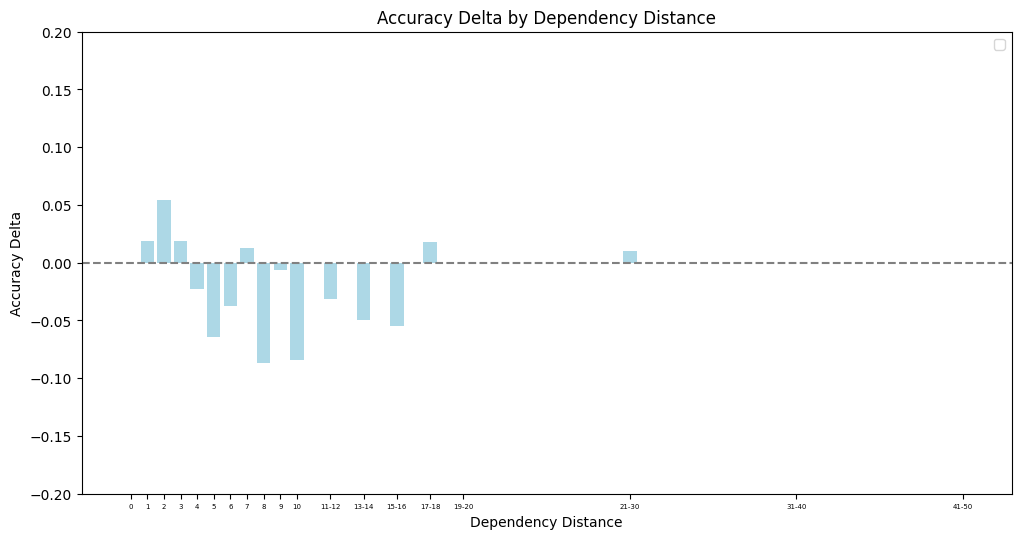

In [ ]:
plot_distance_accuracy(dfs = [df_sent_1, df_sent_2], df_tok = df_tok, plot_delta = True, plot_counts = False)

In [ ]:
def create_linear_baseline(df):
    baseline_matrices = []
    for idx, preds in enumerate(df['prediction']):
        n = preds.shape[0]
        baseline_mat = np.zeros((n, n), dtype=int)
        for i in range(n):
            for j in range(n):
                baseline_mat[i, j] = abs(i - j)
        baseline_matrices.append(baseline_mat)
    return baseline_matrices

baseline_mats = create_linear_baseline(df_sent_1)

In [ ]:
baseline_mats[0]

array([[0, 1, 2, 3, 4, 5, 6],
       [1, 0, 1, 2, 3, 4, 5],
       [2, 1, 0, 1, 2, 3, 4],
       [3, 2, 1, 0, 1, 2, 3],
       [4, 3, 2, 1, 0, 1, 2],
       [5, 4, 3, 2, 1, 0, 1],
       [6, 5, 4, 3, 2, 1, 0]])

In [ ]:
def get_cor_to_baseline(preds, baseline):
    from scipy.stats import spearmanr
    corrs = []
    for pred_mat, base_mat in zip(preds, baseline):
        pred_mat = np.array(pred_mat)
        inds = np.triu_indices_from(pred_mat, k=1)
        pred_m1 = pred_mat[inds]
        base_m2 = base_mat[inds]
        corr, _ = spearmanr(pred_m1, base_m2)
        corrs.append(corr)
    return np.nanmean(corrs)

    

In [ ]:
import yaml

In [ ]:
target_dir = os.path.join(os.getcwd(), 'gpt2_results/mean-pooling')

cols = ['model_layer', 'uuas', 'spearmanr', 'baseline_cor']
rows = []

for name in os.listdir(target_dir):

    path = os.path.join(target_dir, name)
    if not os.path.isdir(path):
            continue
    if os.path.isdir(path):
        for file in os.listdir(path):
            if file.endswith('.yaml'):
                yaml_path = os.path.join(path, file)
                with open(yaml_path, 'r') as f:
                    data = yaml.safe_load(f)
                
                model_layer = data["model"]["model_layer"]
                print(model_layer)
    with open(os.path.join(path, f'dev.uuas'), 'r') as f:
        uuas = f.read().strip()
        print(uuas)
    with open(os.path.join(path, f'dev.spearmanr-5_50-mean'), 'r') as f:
        spearmanr = f.read().strip()
        print(spearmanr)
    df_sent = pd.read_pickle(os.path.join(path, 'dev_by_sentence.pkl'))
    baseline_cor = get_cor_to_baseline(df_sent['prediction'], baseline_mats)
    print(baseline_cor)
    rows.append([model_layer, float(uuas), float(spearmanr), baseline_cor])
df_summary = pd.DataFrame(rows, columns=cols)
df_summary = df_summary.sort_values(by='model_layer')

1
0.6053673994850466
0.6922290866678139
0.4394047920236262
11
0.6560705090116855
0.7367055007051292
0.4207967870606411
5
0.7095464448405625
0.7537565718767161
0.46255031408530456
12
0.6043275896217073
0.6910611644111627
0.3885064483624549
4
0.7053376906318083
0.7418571433221387
0.46212900861136313
9
0.7186076450782333
0.764458669143722
0.4480350947342556
2
0.6605763517528224
0.718257848797394
0.4538554427735525
8
0.7274707862943157
0.7685795614807556
0.4537508316638133
3
0.6817191523073876
0.7305491351316272
0.4651893508226141
0
0.5801148742325213
0.6747780864932333
0.44570606003528956
7
0.7263319469201822
0.7694335657812756
0.4627272250024675
10
0.6871657754010695
0.7560646683782231
0.4398521080301178
6
0.7228659140423846
0.7664673323543879
0.45219987259304095


# Graphic design

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from conllu import parse_incr

In [4]:
df_sent_1 = pd.read_pickle('gpt2_results/mean-pooling/gpt2-parse-distance-2026-1-23-14-8-21-610299/dev_by_sentence.pkl')

In [5]:
def decay_function(d, E, alpha=0.5, n=10):
    if d < E:
        d = 1
    elif d >= E and d < n:
        exponent = 1 / (np.e * alpha)
        d =  1 - ((d-E+1)/(n-E))** exponent
    else:
        d = 0
    return d

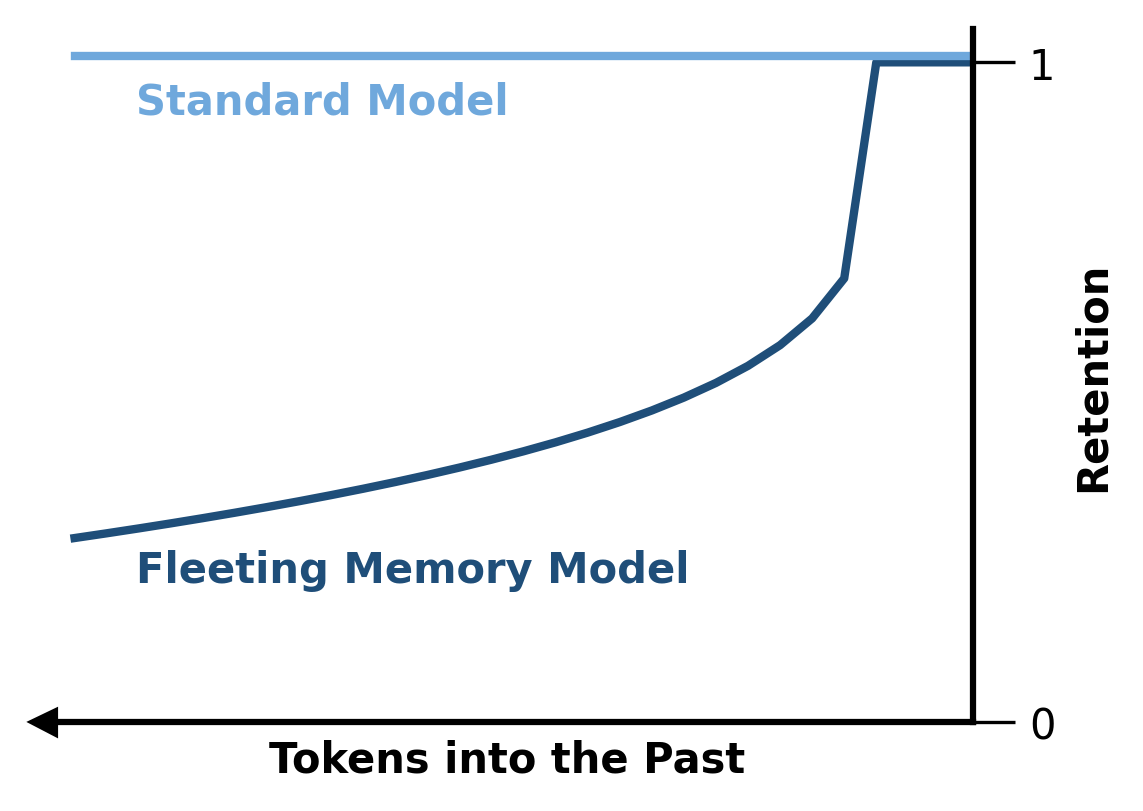

In [6]:
limit = 30
values = [decay_function(d, E = 5, alpha=1.5, n=100) for d in np.arange(1, limit)]

plt.figure(figsize=(4, 3)) # figsize=(8, 3)
plt.plot(np.arange(1, limit), values, color= '#1F4E79', linewidth=2)
plt.plot(np.arange(1, limit), np.ones(limit-1) + 0.01, color= '#6FA8DC', linewidth=2)

plt.gca().invert_xaxis()
plt.gca().yaxis.tick_right()
plt.gca().yaxis.set_label_position("right")
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.ylabel("Retention", fontweight="bold")
plt.xlabel("Tokens into the Past", fontweight="bold")

axis_lw = 1.5
ax = plt.gca()
ax.set_yticks([0, 1])
ax.set_xticks([])
ax.set_ylim(0, 1.05)
ax.set_xlim(limit, 1)

ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["right"].set_linewidth(axis_lw)
ax.tick_params(length=10)

ax.plot([ax.get_xlim()[0]], [0], marker='<', markersize=6, color='black', clip_on=False)

ax.text(0.1, 0.925, "Standard Model", transform=ax.transAxes, ha='left', va='top', 
        fontsize=10, color='#6FA8DC', fontweight="bold")
ax.text(0.1, 0.25, "Fleeting Memory Model", transform=ax.transAxes, ha='left', va='top', 
        fontsize=10, color='#1F4E79', fontweight="bold")

plt.show()

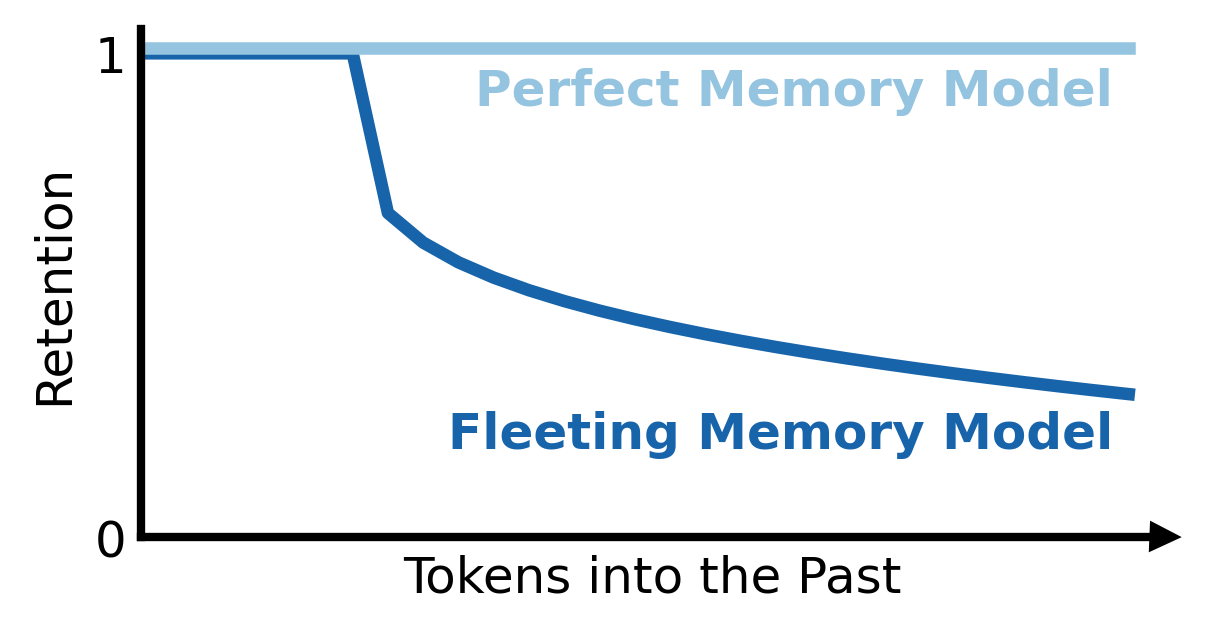

In [84]:
cmap = sns.color_palette("Blues", as_cmap=True)

# mask_color = "#9BE7A3"
# nomask_color = "#2F9E44"

mask_color = cmap(0.8)
nomask_color = cmap(0.4)

limit = 30
values = [decay_function(d, E = 8, alpha=1.5, n=100) for d in np.arange(1, limit)]

plt.figure(figsize=(4*1.1, 2*1.1))
plt.plot(np.arange(1, limit), values, color=mask_color, linewidth=3)
plt.plot(np.arange(1, limit), np.ones(limit-1) + 0.01, color=nomask_color, linewidth=3)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.ylabel("Retention", #fontweight="bold",
           fontsize = 12)
plt.xlabel("Tokens into the Past", #fontweight="bold",
           fontsize = 12)

axis_lw = 2
ax = plt.gca()
ax.set_yticks([0, 1], labels=[0, 1], fontsize=12)
ax.set_xticks([])
ax.set_ylim(0, 1.05)
ax.set_xlim(1, limit)

ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.tick_params(length=0)

ax.plot([ax.get_xlim()[1]], [0], marker='>', markersize=6, color='black', clip_on=False)

ax.text(0.95, 0.925, "Perfect Memory Model", transform=ax.transAxes, ha='right', va='top', 
        fontsize=12, color=nomask_color, fontweight="bold"
        )
ax.text(0.95, 0.25, "Fleeting Memory Model", transform=ax.transAxes, ha='right', va='top', 
        fontsize=12, color=mask_color, fontweight="bold"
        )

plt.show()

/tmp/ipykernel_2862692/4244460882.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold",
/tmp/ipykernel_2862692/4244460882.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold",


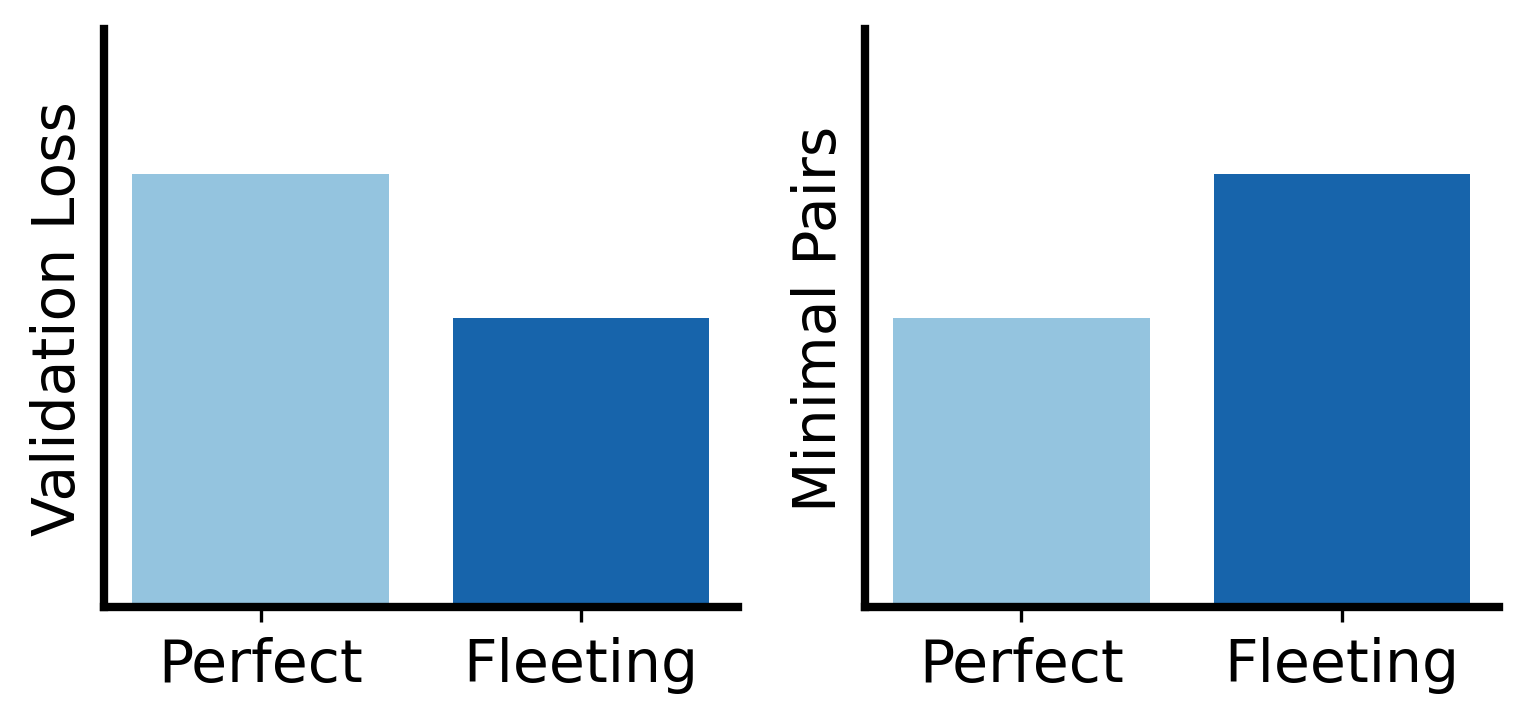

In [98]:
fig, (ax1, ax2) = plt.subplots(figsize=(6, 2.5), ncols=2)


ax1.bar(["Perfect", "Fleeting"], [0.6, 0.4], color=[nomask_color, mask_color])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

ax = ax1
ax.set_ylim(0, 0.8)
ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold", 
                   fontsize= 14)
ax.set_ylabel("Validation Loss", #fontweight="bold", 
              fontsize=14
              )
ax.set_yticks([])


ax2.bar(["Perfect", "Fleeting"], [0.4, 0.6], color=[nomask_color, mask_color])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax = ax2
ax.set_ylim(0, 0.8)
ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold", 
                   fontsize= 14)
ax.set_ylabel("Minimal Pairs", fontsize=14, #fontweight = "bold"
              )
ax.set_yticks([])

plt.show()

In [2]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300       # higher DPI = crisper rendering
mpl.rcParams['savefig.dpi'] = 300       # for saved files

/tmp/ipykernel_2862692/3306199961.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold",
/tmp/ipykernel_2862692/3306199961.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold",


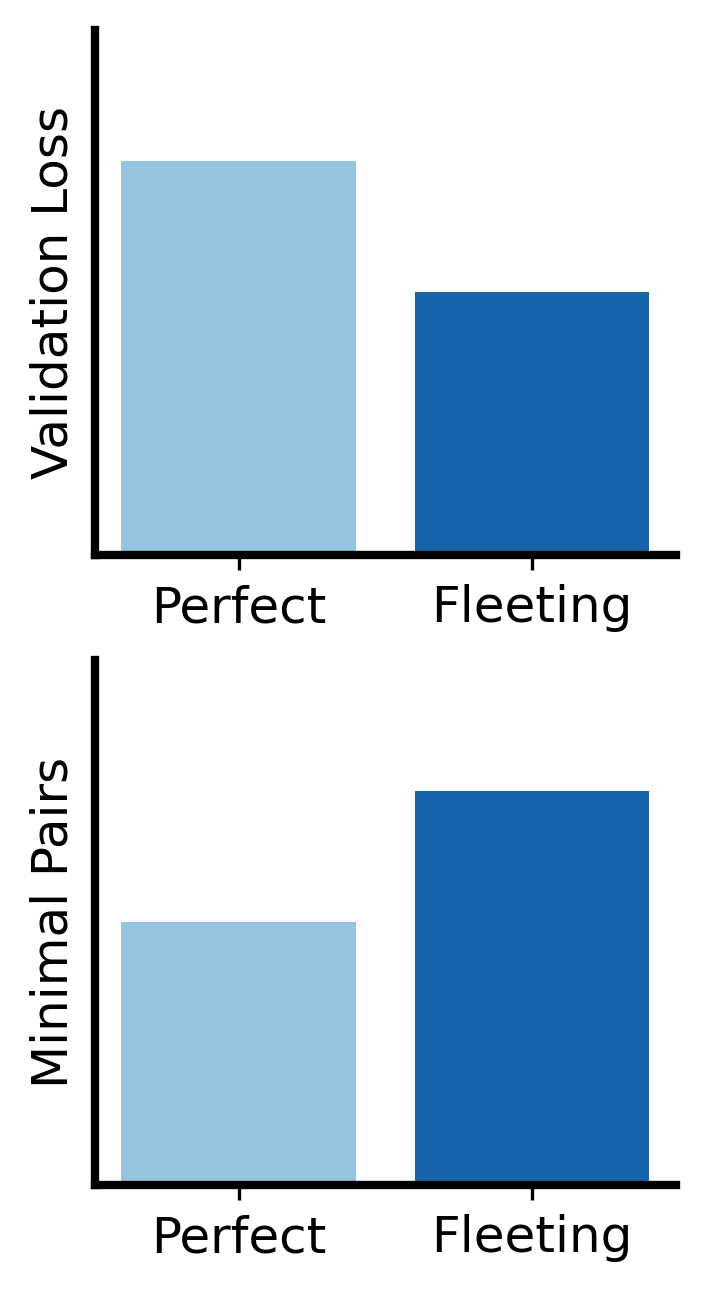

In [23]:
fig, (ax1, ax2) = plt.subplots(figsize=(2.5, 5), nrows=2)


ax1.bar(["Perfect", "Fleeting"], [0.6, 0.4], color=[nomask_color, mask_color])
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

ax = ax1
ax.set_ylim(0, 0.8)
ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold", 
                   fontsize= 12)
ax.set_ylabel("Validation Loss", #fontweight="bold", 
              fontsize=12
              )
ax.set_yticks([])


ax2.bar(["Perfect", "Fleeting"], [0.4, 0.6], color=[nomask_color, mask_color])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax = ax2
ax.set_ylim(0, 0.8)
ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.set_xticklabels(["Perfect", "Fleeting"], #fontweight="bold", 
                   fontsize= 12)
ax.set_ylabel("Minimal Pairs", fontsize=12, #fontweight = "bold"
              )
ax.set_yticks([])

plt.show()

In [25]:
input_path = '../data/en_ewt-ud-dev_cleaned.conllu'
with open(input_path, "r", encoding="utf-8") as fin:
    sentences = list(parse_incr(fin))

In [26]:
test_dict = {
    "sentence": ("The", "keys", "to", "the", "cabinet", "are", "on", "the", "table"),
    "length": 10,
    "label": [[0, 1, 3, 3, 2, 2, 4, 4, 3],
              [1, 0, 2, 2, 1, 1, 3, 3, 2], 
              [3, 2, 0, 2, 1, 3, 5, 5, 4], 
              [3, 2, 2, 0, 1, 3, 5, 5, 4], 
              [2, 1, 1, 1, 0, 2, 4, 4, 3],
              [2, 1, 3, 3, 2, 0, 2, 2, 1],
              [4, 3, 5, 5, 4, 2, 0, 2, 2],
              [4, 3, 5, 5, 4, 2, 2, 0, 2],
              [3, 2, 4, 4, 3, 1, 2, 2, 0]],
    "root_dist": [2, 1, 3, 3, 2, 0, 2, 2, 1]
}
test_dict["prediction"] = np.array(test_dict["label"]) + np.random.normal(0, 0.5, size=(9, 9)) # add some noise

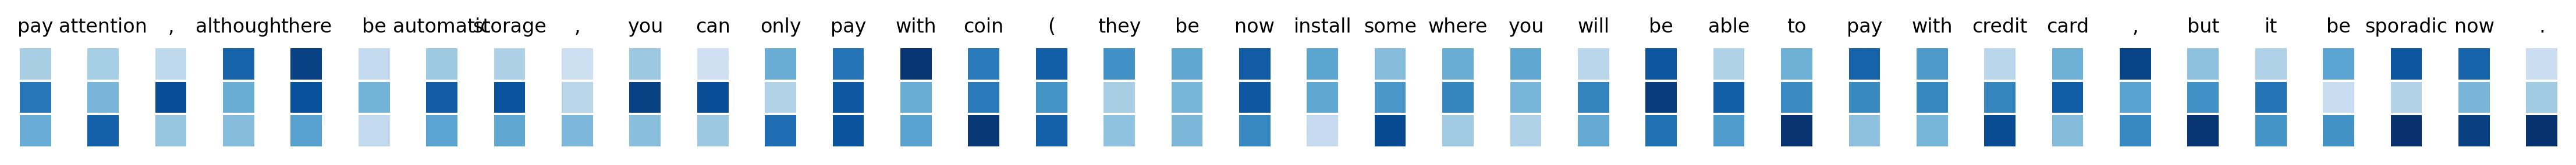

In [27]:
idx = 1227
sentence = [sentences[idx][i]["lemma"] for i in range(len(sentences[idx]))]

n_vectors = len(sentence)
embed_size = 3
vectors = [np.random.uniform(low=-2, high=2, size=(embed_size, 1)) for _ in range(n_vectors)]

fig, axes = plt.subplots(1, n_vectors, figsize=(n_vectors/2, embed_size/4), gridspec_kw={"wspace": 0.05})

for idx, (ax, vec) in enumerate(zip(axes, vectors)):
    sns.heatmap(
        vec,
        cmap="Blues",
        square=True,
        linewidths=0.5,
        linecolor="white",
        vmin = -3,
        vmax = 2,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{sentence[idx]}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [28]:
def distance_matrix_from_sentence(sentence):
    """
    Return (matrix, ids) where matrix[i,j] is the discrete tree distance
    (number of edges) between token ids[i] and ids[j].
    Expects tokens with integer 'id' and 'head' (head==0 means ROOT).
    """

    forms = [tok['form'] for tok in sentence]
    ids = [tok['id'] for tok in sentence if isinstance(tok['id'], int)]
    parent = {tok['id']: (tok['head'] if tok['head'] != 0 else None) for tok in sentence if isinstance(tok['id'], int)}
    
    # Find the root token's id (where head == 0)
    root_id = next(tok['id'] for tok in sentence if isinstance(tok['id'], int) and tok['head'] == 0)
    id_to_idx = {tid: idx for idx, tid in enumerate(ids)}
    root_idx = id_to_idx[root_id]

    def ancestors(n):
        path = [n]
        while parent.get(path[-1]) is not None:
            path.append(parent[path[-1]])
        return path  # from node up to root

    depths = {i: len(ancestors(i)) - 1 for i in ids}  # distance to root
    n = len(ids)
    mat = np.zeros((n, n), dtype=int)

    # compute pairwise distances via lowest common ancestor (LCA)
    for i, a in enumerate(ids):
        anc_a = ancestors(a)
        set_anc_a = set(anc_a)
        for j, b in enumerate(ids):
            if i == j:
                continue
            anc_b = ancestors(b)
            # find first common ancestor
            lca = next((x for x in anc_b if x in set_anc_a), None)
            mat[i, j] = depths[a] + depths[b] - 2 * depths[lca]

    root_dist = mat[root_idx, :]
    return mat, ids, root_dist, forms

def graph_from_distance_matrix(mat, ids, root_dist, forms, ax=None, node_size = 1500, font_size = 12, width = 2, plot = True, preds=None):

    # Compute MST using Kruskal’s algorithm
    G = nx.from_numpy_array(mat#[:-1, :-1]
                            ) # remove last element
    mst = nx.minimum_spanning_tree(G, algorithm="kruskal")
    adj_matrix = nx.to_numpy_array(mst)
    # Prepare node positions: x=ids, y=root_dist, to get a readable plot
    pos = {i: (id, len(root_dist) - root_dist[idx]) for idx, (i, id) in enumerate(zip(range(len(ids)), ids))}

    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
        
        # Draw MST edges (gold)
        nx.draw_networkx_edges(
            mst,
            pos=pos,
            ax=ax,
            edge_color='lightgrey',
            width=width,
        )
        
        # Draw predicted edges if provided
        if preds is not None:

            pred_G = nx.from_numpy_array(preds[:-1, :-1])
            pred_mst = nx.minimum_spanning_tree(pred_G, algorithm="kruskal")
            common_edges = set(mst.edges()) & set(pred_mst.edges())
            false_edges = set(pred_mst.edges()) - common_edges

            nx.draw_networkx_edges(
                mst,
                edgelist=list(common_edges),
                pos=pos,
                ax=ax,
                edge_color='royalblue',
                width=width,
                #style='dotted'
            )

            nx.draw_networkx_edges(
                mst,
                edgelist=list(false_edges),
                pos=pos,
                ax=ax,
                edge_color='red',
                width=width,
                style='dotted'
            )

        
        # Draw nodes and labels
        nx.draw_networkx_nodes(
            mst,
            pos=pos,
            ax=ax,
            node_color='lightblue',
            node_size=node_size
        )
        nx.draw_networkx_labels(
            mst,
            pos=pos,
            ax=ax,
            labels={i: forms[i] for i in range(len(forms))},
            font_size=font_size
        )
        
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.xaxis.set_label_position("top")
        ax.set_xlabel("Linear distance", fontweight="bold")
        ax.set_ylabel("Depth", fontweight="bold")
        ax.spines["bottom"].set_linewidth(axis_lw)

    return adj_matrix, ax

In [29]:
test_dict = {
    "sentence": ("The", "keys", "to", "the", "cabinet", "are", "on", "the", "table"),
    "length": 10,
    "label": [[0, 1, 3, 3, 2, 2, 4, 4, 3],
              [1, 0, 2, 2, 1, 1, 3, 3, 2], 
              [3, 2, 0, 2, 1, 3, 5, 5, 4], 
              [3, 2, 2, 0, 1, 3, 5, 5, 4], 
              [2, 1, 1, 1, 0, 2, 4, 4, 3],
              [2, 1, 3, 3, 2, 0, 2, 2, 1],
              [4, 3, 5, 5, 4, 2, 0, 2, 2],
              [4, 3, 5, 5, 4, 2, 2, 0, 2],
              [3, 2, 4, 4, 3, 1, 2, 2, 0]],
    "root_dist": [2, 1, 3, 3, 2, 0, 2, 2, 1]
}
test_dict["prediction"] = np.array(test_dict["label"]) + np.random.normal(0, 0.5, size=(9, 9)) # add some noise

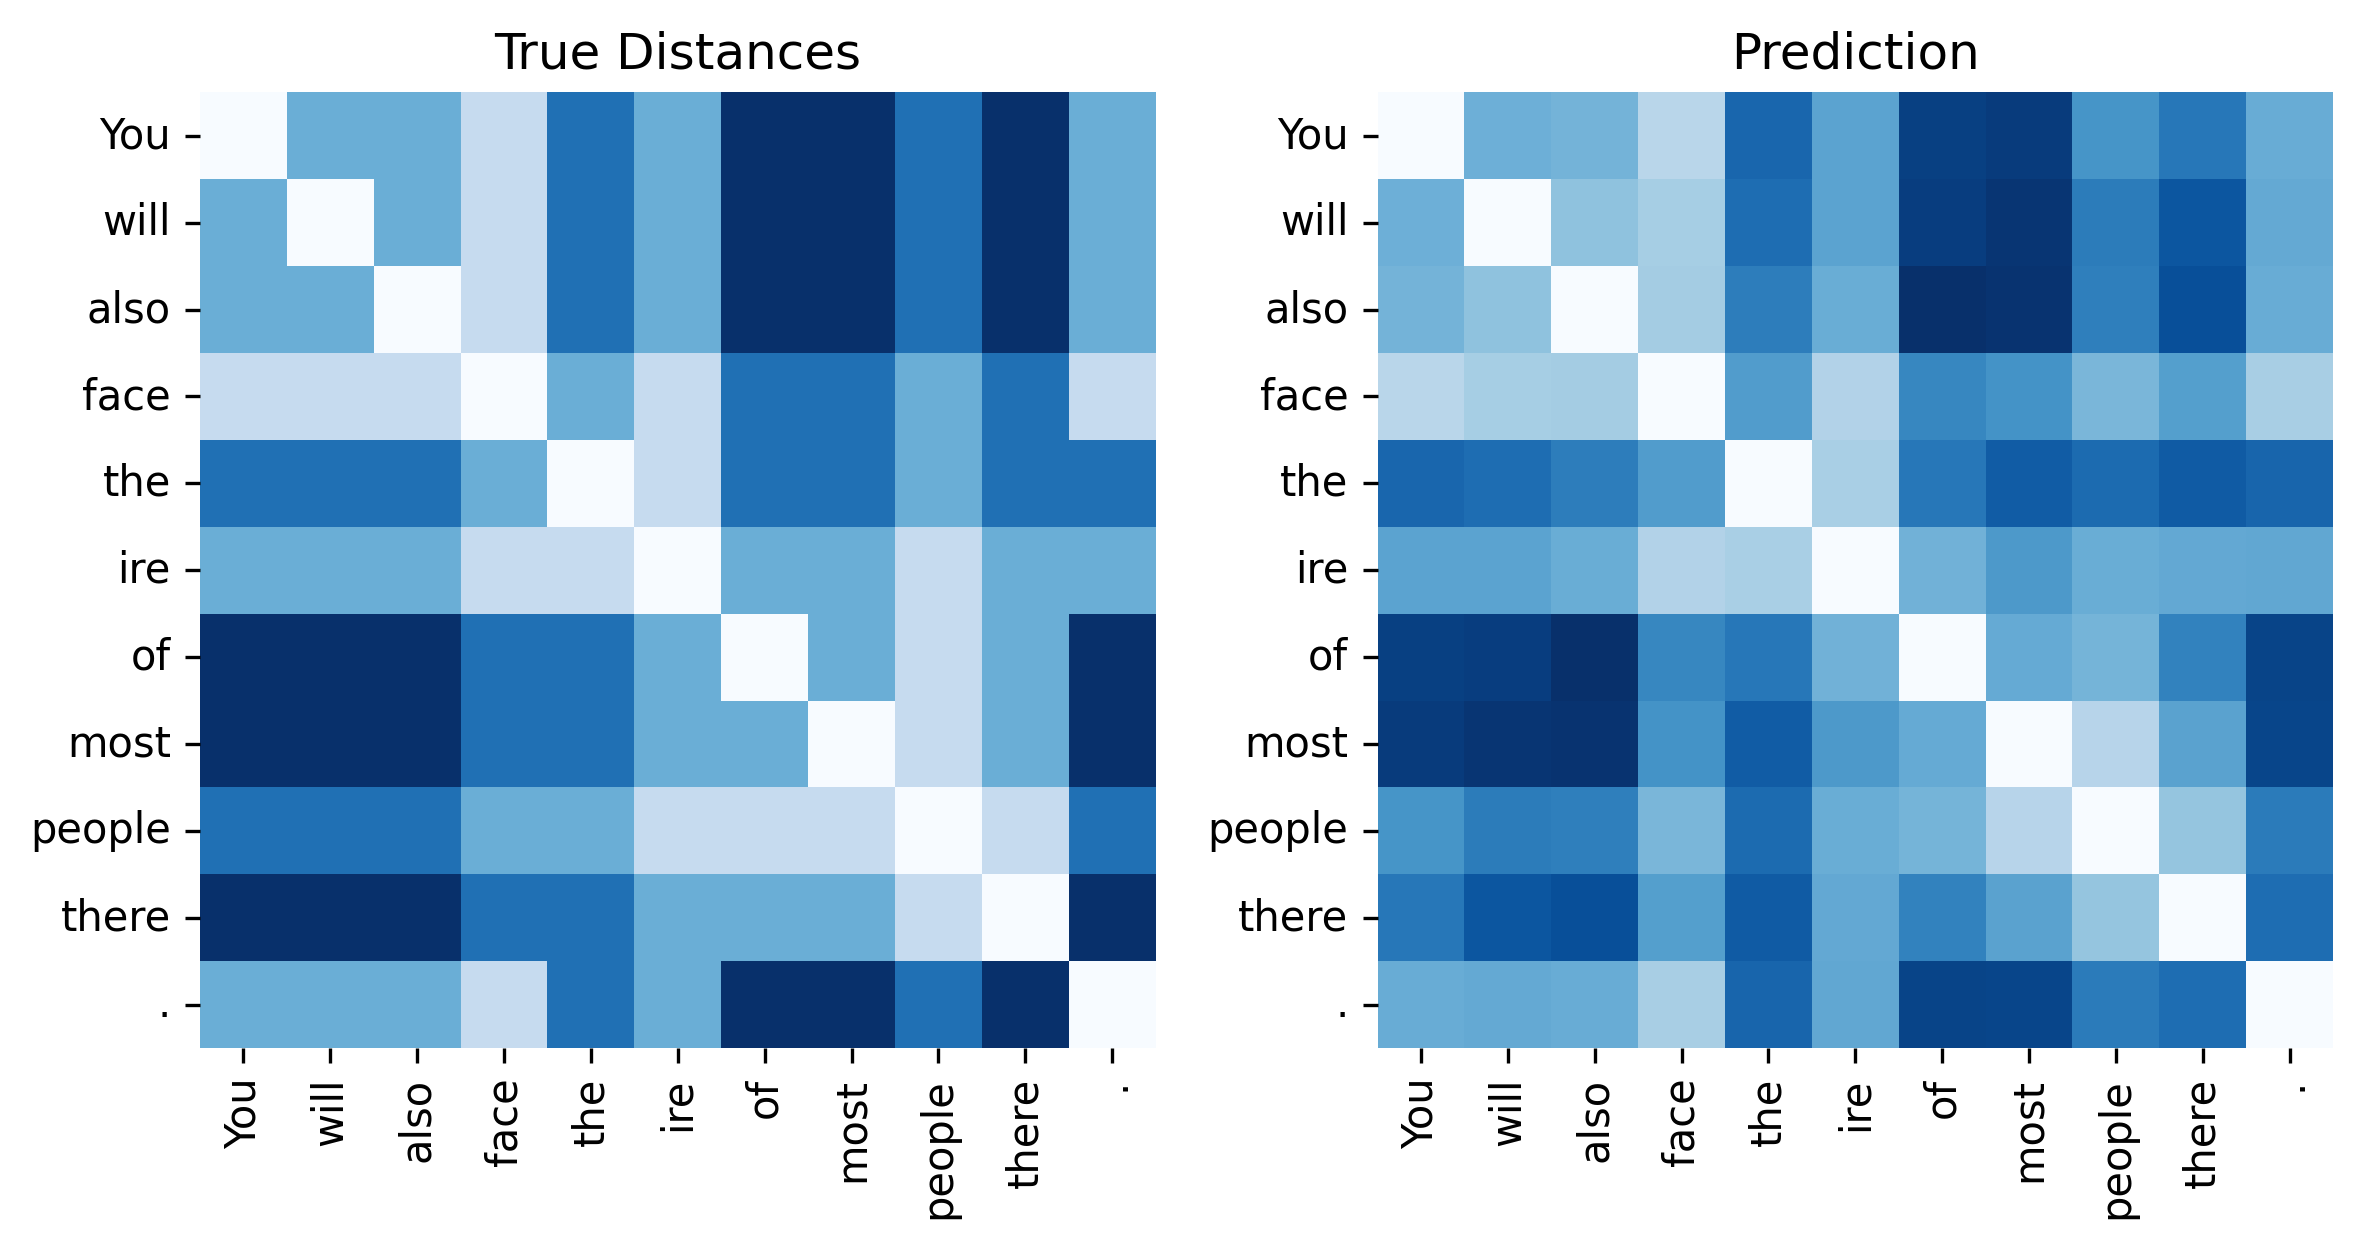

In [30]:
idx = 1228
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4),
    squeeze=False
)

# Set heatmaps
sns.heatmap(df_sent_1['label'][idx], cmap="Blues", ax=ax[0, 0], square=True, cbar= False)
sns.heatmap(df_sent_1['prediction'][idx], cmap="Blues", ax=ax[0, 1], square=True, cbar= False)

# Set axis labels to the sentence tokens
sentence_tokens = df_sent_1["sentence"][idx]
ax[0, 0].set_xticklabels(sentence_tokens, rotation=90)
ax[0, 0].set_yticklabels(sentence_tokens, rotation=0)
ax[0, 1].set_xticklabels(sentence_tokens, rotation=90)
ax[0, 1].set_yticklabels(sentence_tokens, rotation=0)

ax[0, 0].set_title("True Distances")
ax[0, 1].set_title("Prediction")

plt.tight_layout()
plt.show()

In [31]:
def graph_from_distance_matrix(mat, ids, root_dist, forms, ax=None, node_size = 1500, font_size = 12, width = 2, plot = True, preds=None):

    # Compute MST using Kruskal's algorithm
    G = nx.from_numpy_array(mat)
    mst = nx.minimum_spanning_tree(G, algorithm="kruskal")
    adj_matrix = nx.to_numpy_array(mst)
    # Prepare node positions: x=ids, y=root_dist, to get a readable plot
    pos = {i: (id, len(root_dist) - root_dist[idx]) for idx, (i, id) in enumerate(zip(range(len(ids)), ids))}

    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
        
        # Draw MST edges (gold) with Manhattan-style routing
        nx.draw_networkx_edges(
            mst,
            pos=pos,
            ax=ax,
            edge_color='lightgrey',
            width=width,
            connectionstyle="arc3,rad=0",  # Straight lines for gold
        )
        
        # Draw predicted edges if provided
        if preds is not None:

            pred_G = nx.from_numpy_array(preds)
            pred_mst = nx.minimum_spanning_tree(pred_G, algorithm="kruskal")
            common_edges = set(mst.edges()) & set(pred_mst.edges())
            false_edges = set(pred_mst.edges()) - common_edges

            # Common edges: Manhattan-style (right-angled)
            nx.draw_networkx_edges(
                mst,
                edgelist=list(common_edges),
                pos=pos,
                ax=ax,
                edge_color='royalblue',
                width=width,
                # connectionstyle="angle3,angleA=0,angleB=90",  # Manhattan style
            )

            # False edges: Direct lines
            nx.draw_networkx_edges(
                mst,
                edgelist=list(false_edges),
                pos=pos,
                ax=ax,
                edge_color='red',
                width=width,
                style='dotted',
                # connectionstyle="arc3,rad=0",  # Straight lines
            )

        
        # Draw nodes and labels
        nx.draw_networkx_nodes(
            mst,
            pos=pos,
            ax=ax,
            node_color='lightblue',
            node_size=node_size
        )
        nx.draw_networkx_labels(
            mst,
            pos=pos,
            ax=ax,
            labels={i: forms[i] for i in range(len(forms))},
            font_size=font_size
        )
        
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.xaxis.set_label_position("top")
        ax.set_xlabel("Linear distance", fontweight="bold")
        ax.set_ylabel("Depth", fontweight="bold")
        ax.spines["bottom"].set_linewidth(axis_lw)

    return adj_matrix, ax

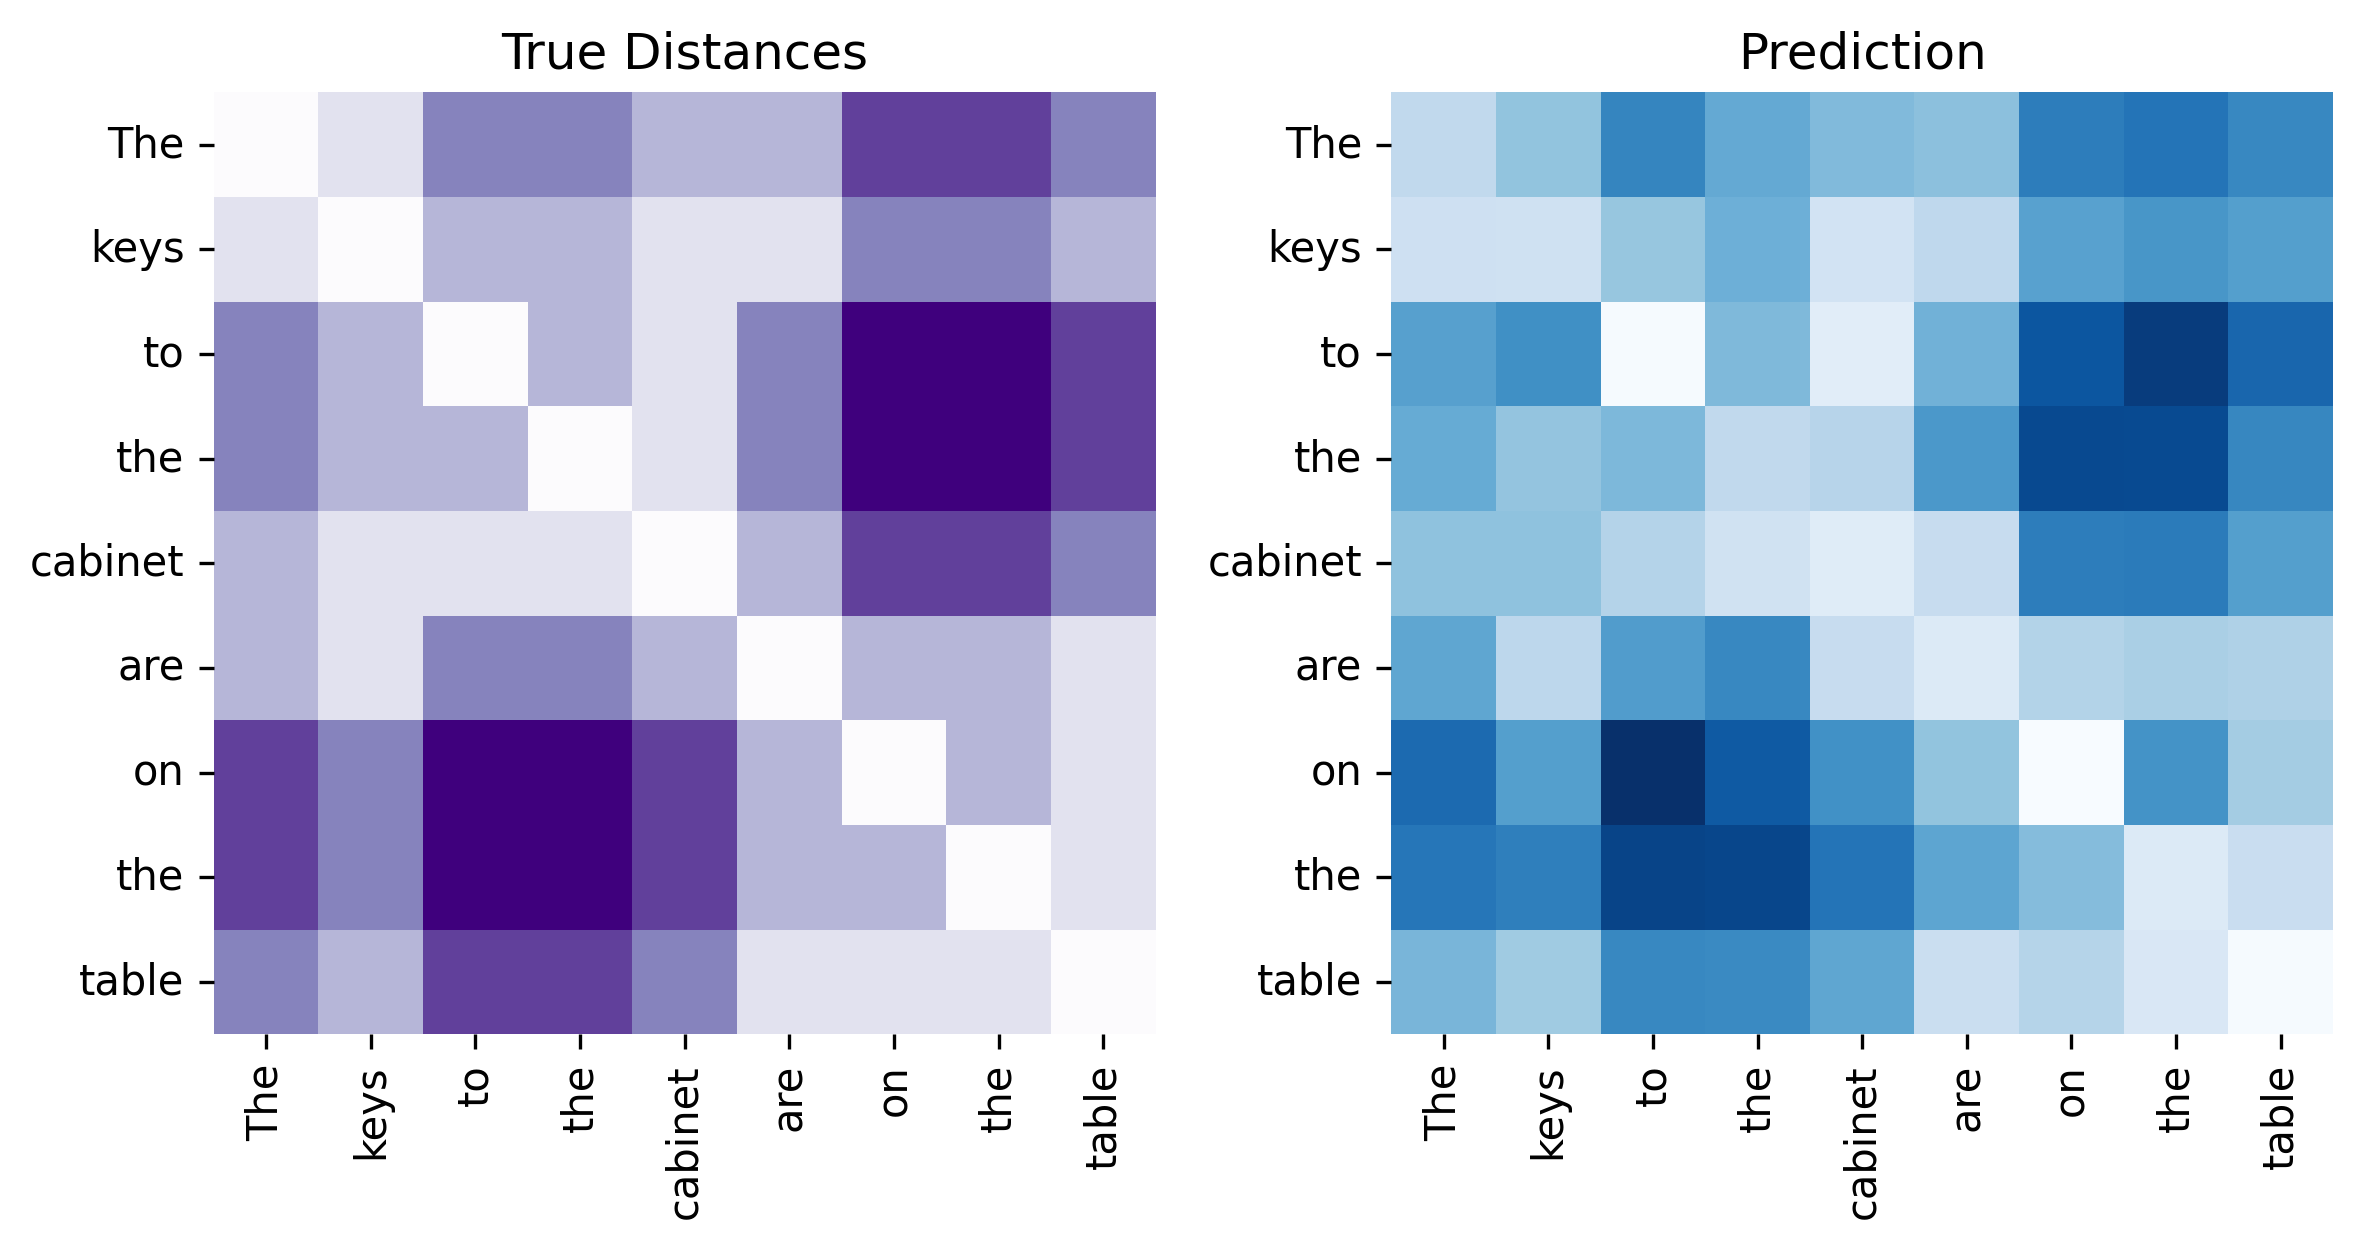

In [32]:
test_dict = {
    "sentence": ("The", "keys", "to", "the", "cabinet", "are", "on", "the", "table"),
    "length": 10,
    "label": [[0, 1, 3, 3, 2, 2, 4, 4, 3], # the
              [1, 0, 2, 2, 1, 1, 3, 3, 2], # keys
              [3, 2, 0, 2, 1, 3, 5, 5, 4], # to 
              [3, 2, 2, 0, 1, 3, 5, 5, 4], # the
              [2, 1, 1, 1, 0, 2, 4, 4, 3], # cabinet
              [2, 1, 3, 3, 2, 0, 2, 2, 1], # are
              [4, 3, 5, 5, 4, 2, 0, 2, 1], # on
              [4, 3, 5, 5, 4, 2, 2, 0, 1], # the
              [3, 2, 4, 4, 3, 1, 1, 1, 0]],# table
              
    "root_dist": [2, 1, 3, 3, 2, 0, 2, 2, 1]
}
test_dict["prediction"] = np.array(test_dict["label"]) + np.random.normal(0, 0.5, size=(9, 9)) # add some noise
test_dict["prediction"][4, 5] = 0.8
test_dict["prediction"][5, 4] = 0.8

idx = 1228
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4),
    squeeze=False
)

# Set heatmaps
sns.heatmap(test_dict['label'], cmap="Purples", ax=ax[0, 0], square=True, cbar= False)
sns.heatmap(test_dict['prediction'], cmap="Blues", ax=ax[0, 1], square=True, cbar= False)

# Set axis labels to the sentence tokens
sentence_tokens = test_dict["sentence"]
ax[0, 0].set_xticklabels(sentence_tokens, rotation=90)
ax[0, 0].set_yticklabels(sentence_tokens, rotation=0)
ax[0, 1].set_xticklabels(sentence_tokens, rotation=90)
ax[0, 1].set_yticklabels(sentence_tokens, rotation=0)

ax[0, 0].set_title("True Distances")
ax[0, 1].set_title("Prediction")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2862692/3443581704.py:15: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


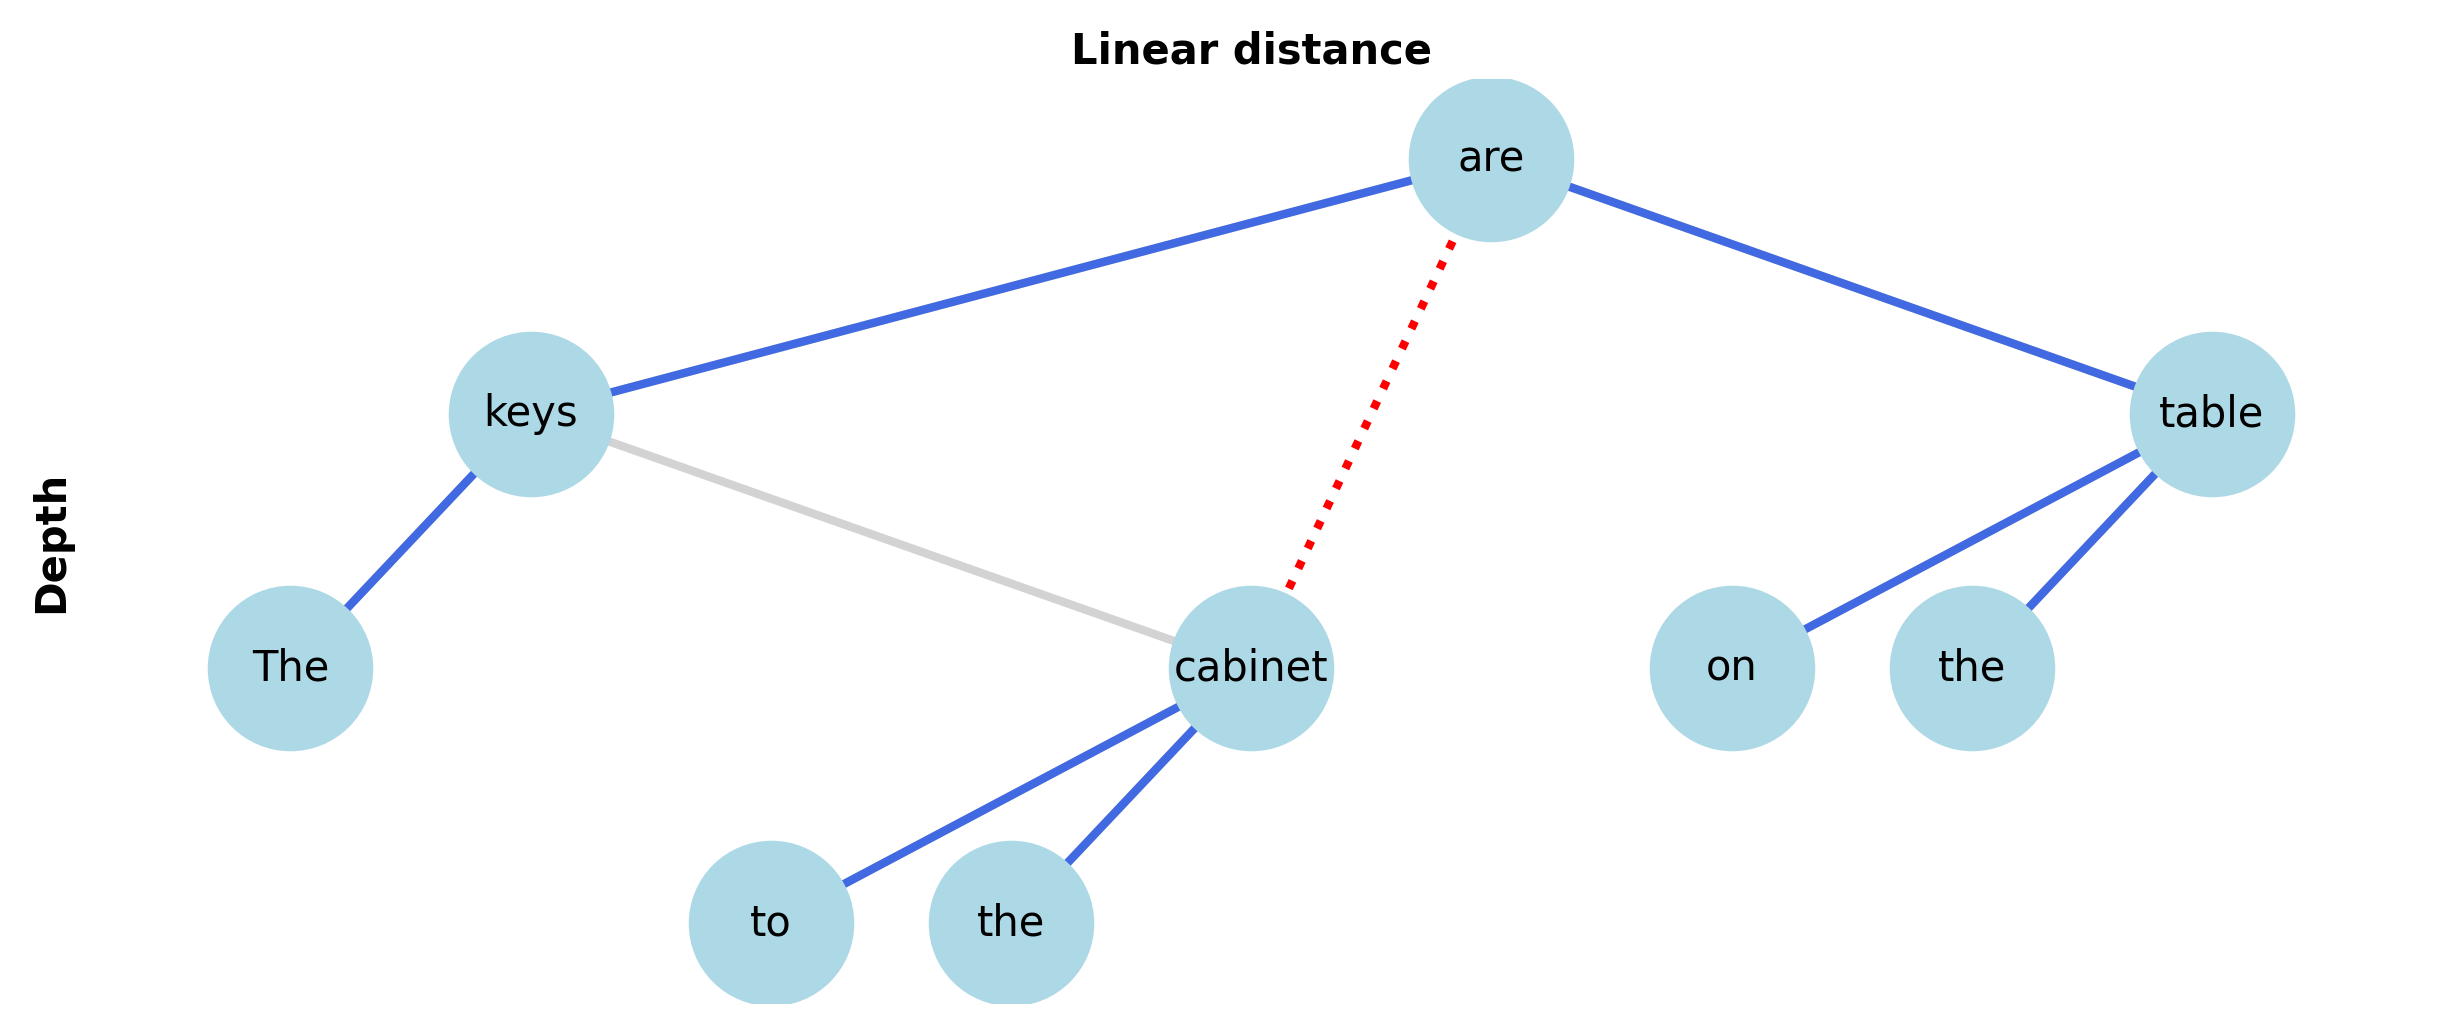

In [33]:
# mat, ids, root_dist, forms = distance_matrix_from_sentence(sentences[idx])
fig, axs = plt.subplots(1, 1, figsize=(10, 4))
graph_from_distance_matrix(np.array(test_dict['label']), np.arange(len(test_dict['label'])) + 1, test_dict['root_dist'], 
                           test_dict['sentence'], ax=axs, 
                           preds=test_dict['prediction'], node_size=1500, font_size=10, width=2
                           )
plt.show()

/tmp/ipykernel_2862692/3443581704.py:15: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


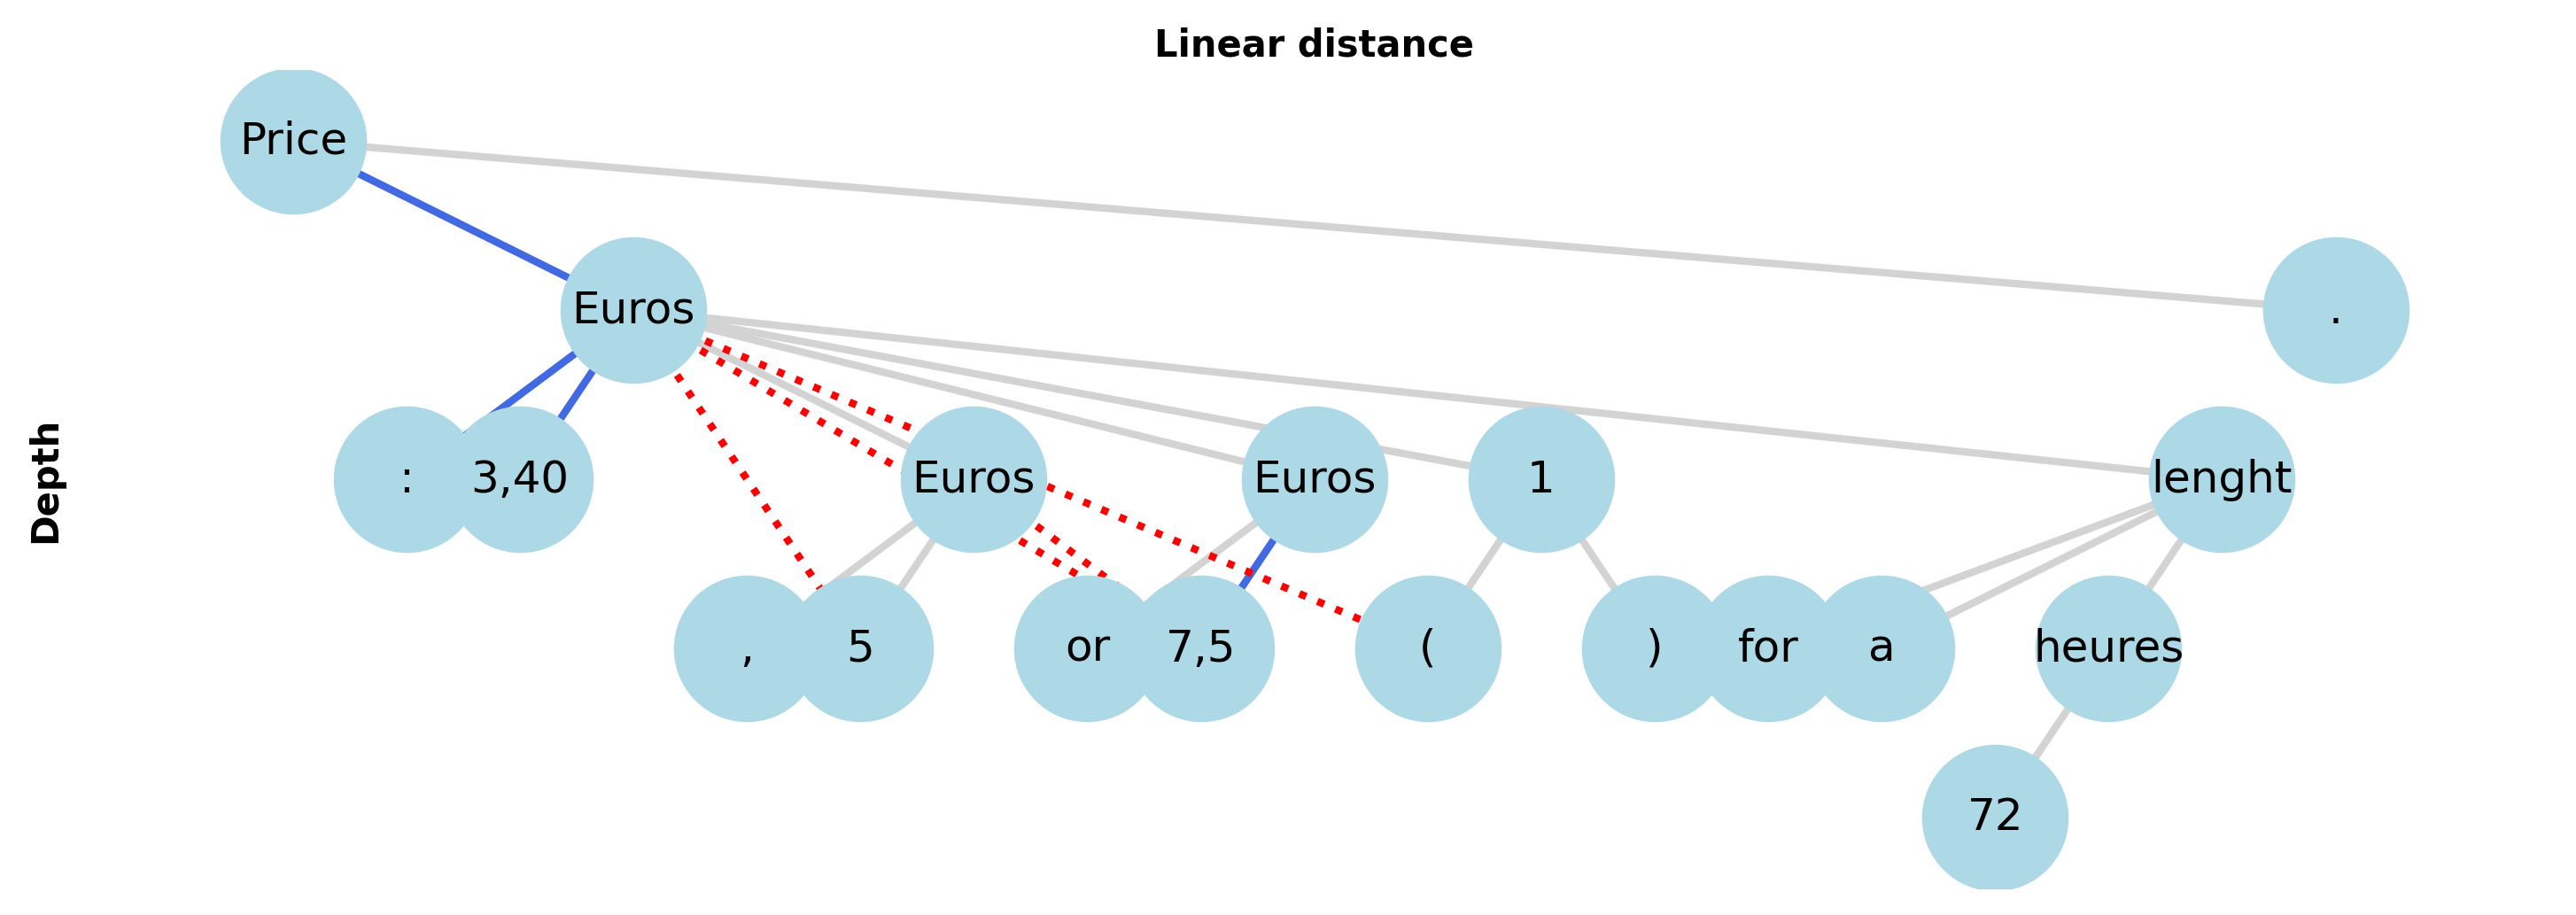

In [34]:
mat, ids, root_dist, forms = distance_matrix_from_sentence(sentences[idx])
fig, axs = plt.subplots(1, 1, figsize=(12, 4))
graph_from_distance_matrix(mat, ids, root_dist, forms, ax=axs, 
                           preds=df_sent_1['prediction'][idx]
                           )
plt.show()

In [35]:
def graph_from_distance_matrix_highlight(mat, ids, root_dist, forms, ax=None, node_size = 1500, font_size = 12, width = 2, plot = True, preds=None, highlight_edges=None, highlight_color="orange"):

    # Compute MST using Kruskal’s algorithm
    G = nx.from_numpy_array(mat)
    mst = nx.minimum_spanning_tree(G, algorithm="kruskal")
    adj_matrix = nx.to_numpy_array(mst)
    # Prepare node positions: x=ids, y=root_dist, to get a readable plot
    pos = {i: (id, len(root_dist) - root_dist[idx]) for idx, (i, id) in enumerate(zip(range(len(ids)), ids))}

    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
        
        # Draw MST edges (gold)
        nx.draw_networkx_edges(
            mst,
            pos=pos,
            ax=ax,
            edge_color='lightgrey',
            width=width,
        )

        # Highlight selected edges (by node indices)

        if highlight_edges:
            for i in range(len(highlight_edges)):
                nx.draw_networkx_edges(
                    mst,
                    pos=pos,
                    ax=ax,
                    edgelist=highlight_edges[i],
                    edge_color=highlight_color[i],
                    width=width + 1.5,
                )
        
        # Draw nodes and labels
        nx.draw_networkx_nodes(
            mst,
            pos=pos,
            ax=ax,
            node_color='lightblue',
            node_size=node_size
        )
        nx.draw_networkx_labels(
            mst,
            pos=pos,
            ax=ax,
            labels={i: forms[i] for i in range(len(forms))},
            font_size=font_size
        )
        
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.xaxis.set_label_position("top")
        ax.set_xlabel("Linear distance", fontweight="bold")
        ax.set_ylabel("Depth", fontweight="bold")
        ax.spines["bottom"].set_linewidth(axis_lw)

    return adj_matrix, ax

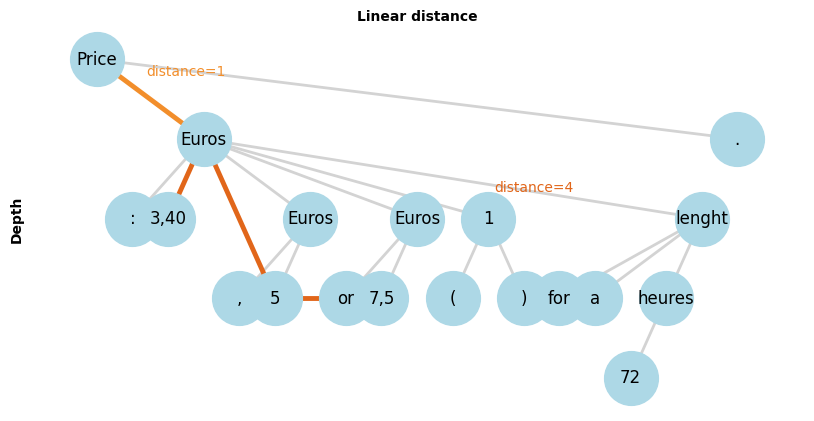

In [70]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
highlight = [[(0, 3)], [(2, 3), (3, 5), (5, 8), (8, 7)]]
mat, ids, root_dist, forms = distance_matrix_from_sentence(sentences[idx])
graph_from_distance_matrix_highlight(
    mat, ids, root_dist, forms,
    ax=ax,
    highlight_edges=highlight,
    highlight_color=["#F28E2B", "#E1661AFF"]
)
ax.text(0.15, 0.9, "distance=1", transform=ax.transAxes, ha='left', va='top', 
        fontsize=10, color="#F28E2B")
ax.text(0.6, 0.6, "distance=4", transform=ax.transAxes, ha='left', va='top', 
        fontsize=10, color="#E1661AFF")

plt.show()

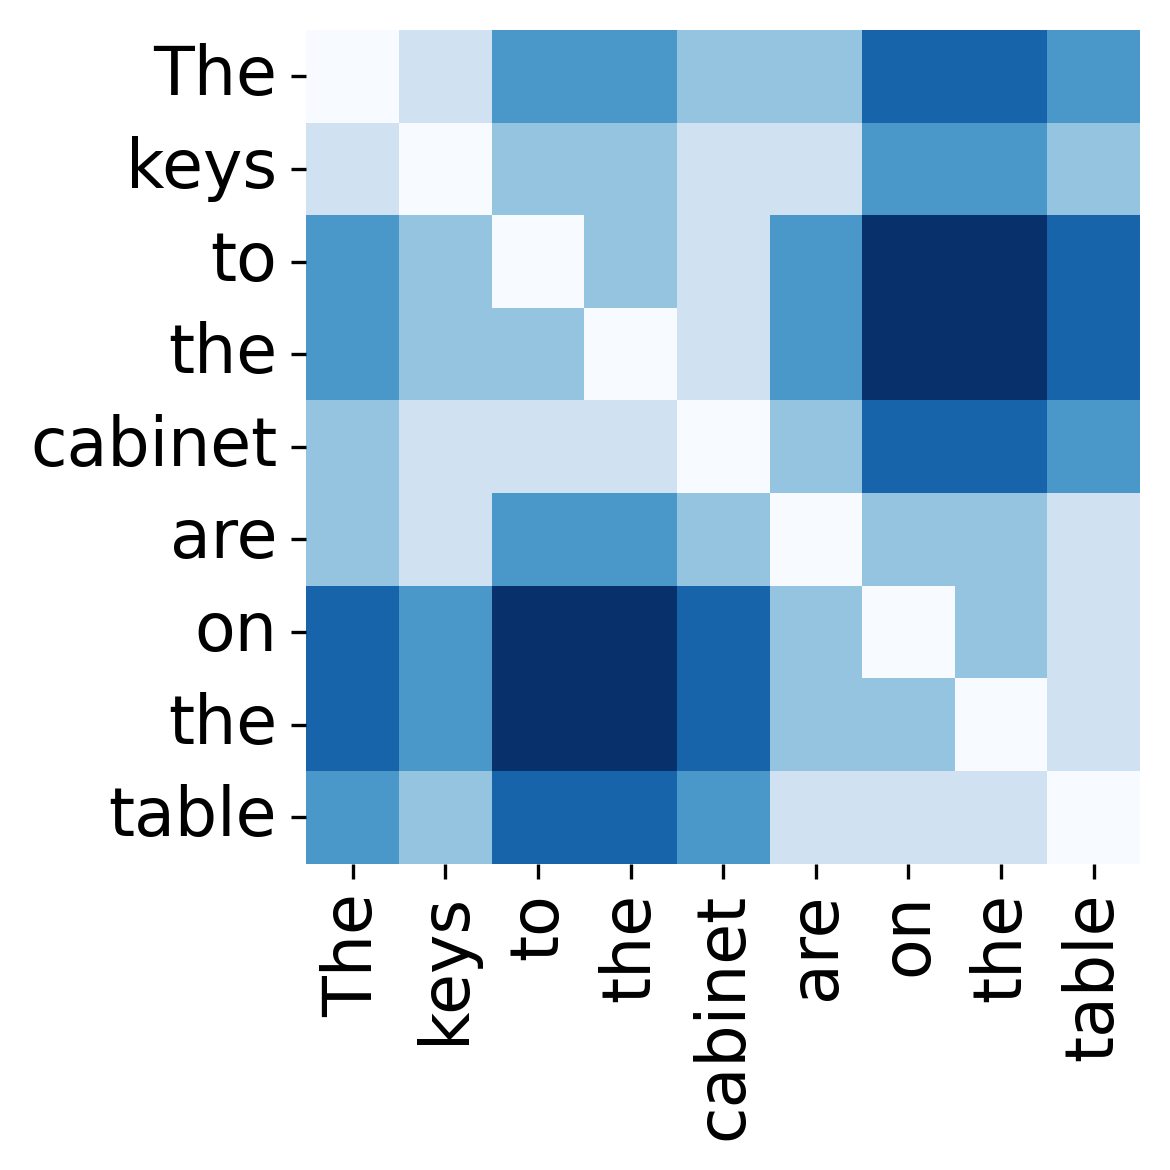

In [37]:
idx = 1228
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(4, 4),
    squeeze=False
)


# Set heatmaps
sns.heatmap(np.array(test_dict["label"]), cmap="Blues", ax=ax[0, 0], square=True, cbar= False)
# sns.heatmap(df_sent_1['prediction'][idx], cmap="Blues", ax=ax[0, 1], square=True, cbar= False)

# Set axis labels to the sentence tokens
sentence_tokens = test_dict["sentence"]
ax[0, 0].set_xticklabels(sentence_tokens, rotation=90, fontsize=16)
ax[0, 0].set_yticklabels(sentence_tokens, rotation=0, fontsize=16)

# ax[0, 0].set_xticklabels([], rotation=90, fontsize=16)
# ax[0, 0].set_yticklabels([], rotation=0, fontsize=16)

# ax[0, 0].set_title("True Distances")

import matplotlib.patches as patches
# ax[0, 0].add_patch(
#     patches.Rectangle((5, 3), 1, 1, fill=False, edgecolor="#F28E2B", linewidth=2)
# )
# ax[0, 0].add_patch(
#     patches.Rectangle((7, 2), 1, 1, fill=False, edgecolor="#E1661AFF", linewidth=2)
# )
plt.tight_layout()
plt.show()

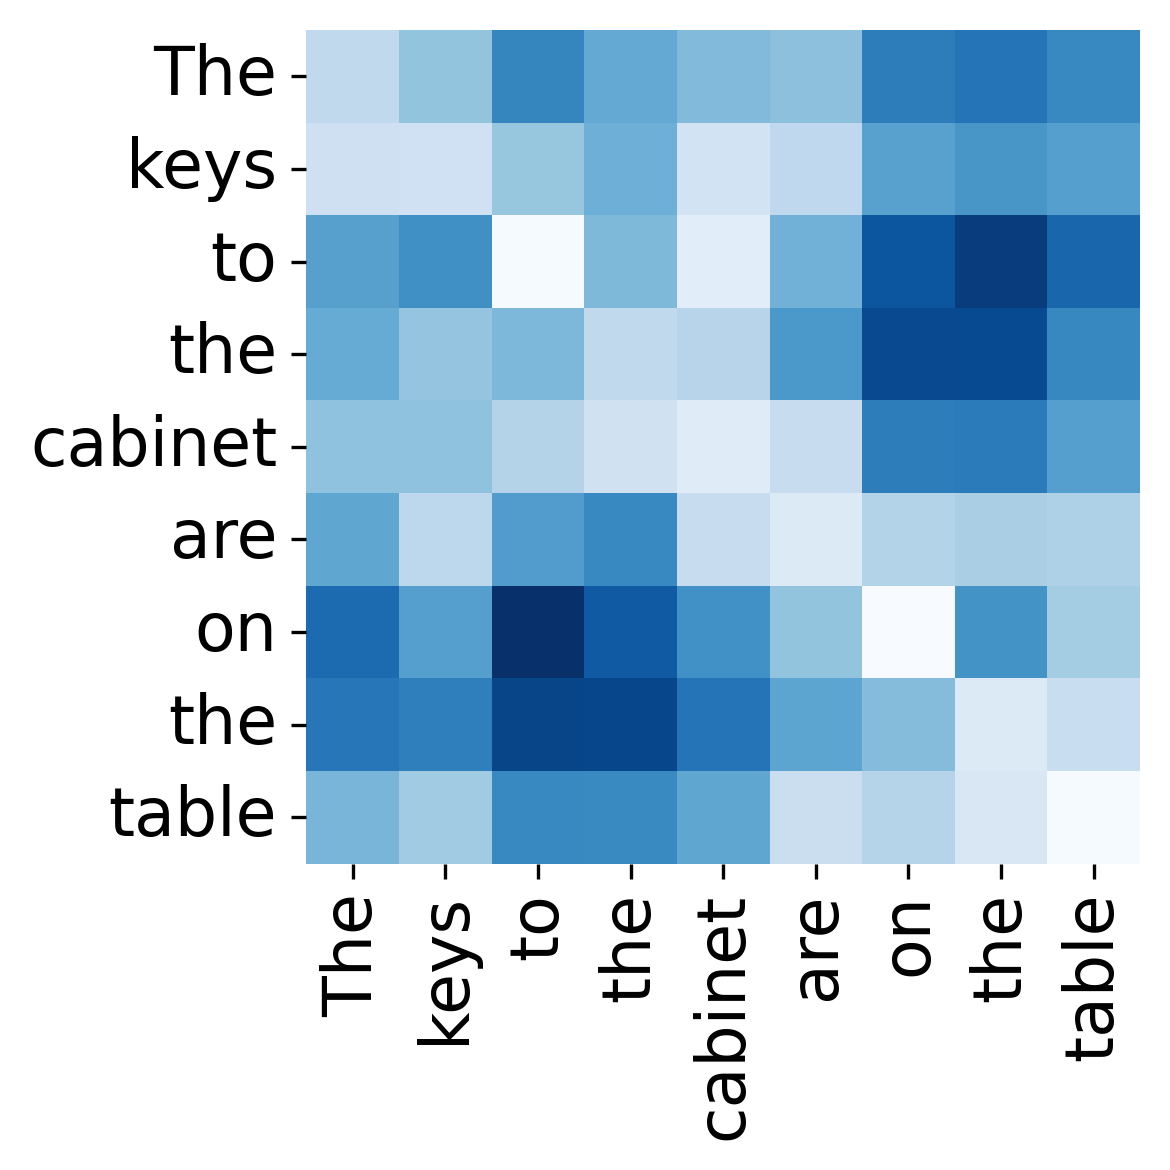

In [38]:
idx = 1228
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(4, 4),
    squeeze=False
)

# Set heatmaps
sns.heatmap(np.array(test_dict["prediction"]), cmap="Blues", ax=ax[0, 0], square=True, cbar= False)

# Set axis labels to the sentence tokens
sentence_tokens = test_dict["sentence"]
ax[0, 0].set_xticklabels(sentence_tokens, rotation=90, fontsize=16)
ax[0, 0].set_yticklabels(sentence_tokens, rotation=0, fontsize=16)
plt.tight_layout()
plt.show()

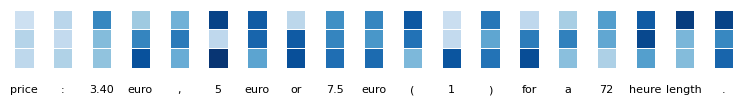

In [24]:
idx = 1228
sentence = [sentences[idx][i]["lemma"] for i in range(len(sentences[idx]))]

n_vectors = len(sentence)
embed_size = 3
vectors = [np.random.uniform(low=-2, high=2, size=(embed_size, 1)) for _ in range(n_vectors)]

fig, axes = plt.subplots(1, n_vectors, figsize=(n_vectors/2, embed_size/4), gridspec_kw={"wspace": 0.05})

for idx, (ax, vec) in enumerate(zip(axes, vectors)):
    sns.heatmap(
        vec,
        cmap="Blues",
        square=True,
        linewidths=0.5,
        linecolor="white",
        vmin = -3,
        vmax = 2,
        cbar=False,
        ax=ax,
    )
    ax.text(0.5, -0.3, f"{sentence[idx]}", fontsize=8, ha='center', va='top', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

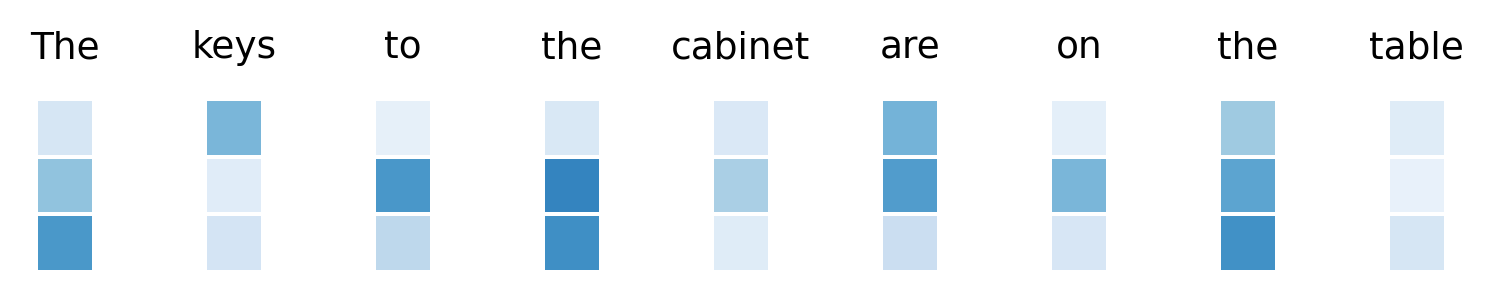

In [54]:
test_dict = {
    "sentence": ("The", "keys", "to", "the", "cabinet", "are", "on", "the", "table"),
    "length": 10,
    "label": [[0, 1, 3, 3, 2, 2, 4, 4, 3], # the
              [1, 0, 2, 2, 1, 1, 3, 3, 2], # keys
              [3, 2, 0, 2, 1, 3, 5, 5, 4], # to 
              [3, 2, 2, 0, 1, 3, 5, 5, 4], # the
              [2, 1, 1, 1, 0, 2, 4, 4, 3], # cabinet
              [2, 1, 3, 3, 2, 0, 2, 2, 1], # are
              [4, 3, 5, 5, 4, 2, 0, 2, 1], # on
              [4, 3, 5, 5, 4, 2, 2, 0, 1], # the
              [3, 2, 4, 4, 3, 1, 1, 1, 0]],# table
              
    "root_dist": [2, 1, 3, 3, 2, 0, 2, 2, 1]
}

sentence =test_dict["sentence"]

n_vectors = len(sentence)
embed_size = 3
vectors = [np.random.uniform(low=0, high=1, size=(embed_size, 1)) for _ in range(n_vectors)]

fig, axes = plt.subplots(
    1,
    n_vectors,
    figsize=(n_vectors*0.7, embed_size/4)
)

fig.subplots_adjust(wspace=0.5)

for idx, (ax, vec) in enumerate(zip(axes, vectors)):
    sns.heatmap(
        vec,
        cmap="Blues",
        square=True,
        linewidths=0.5,
        linecolor="white",
        vmin = -0.1,
        vmax = 1.5,
        cbar=False,
        ax=ax,
    )
    ax.text(0.5, 1.4, f"{sentence[idx]}", fontsize=9, ha='center', va='top', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [9]:
sentence = test_dict["sentence"][:3]

n_vectors = len(sentence)
embed_size = 3
vectors = [np.random.uniform(low=0, high=1, size=(embed_size, 1)) for _ in range(n_vectors)]

fig, axes = plt.subplots(
    n_vectors, 1,
    figsize=(embed_size/2, n_vectors/2),
    gridspec_kw={"hspace": 1}
)

for idx, (ax, vec) in enumerate(zip(axes, vectors)):
    sns.heatmap(
        vec.T,
        cmap="Blues",
        square=True,
        linewidths=0.5,
        linecolor="white",
        vmin=-2,
        vmax=1,
        cbar=False,
        ax=ax,
    )
    ax.text(
        -0.1, 0.5,
        sentence[idx],
        fontsize=12,
        ha="right",
        va="center",
        transform=ax.transAxes,
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

NameError: name 'test_dict' is not defined

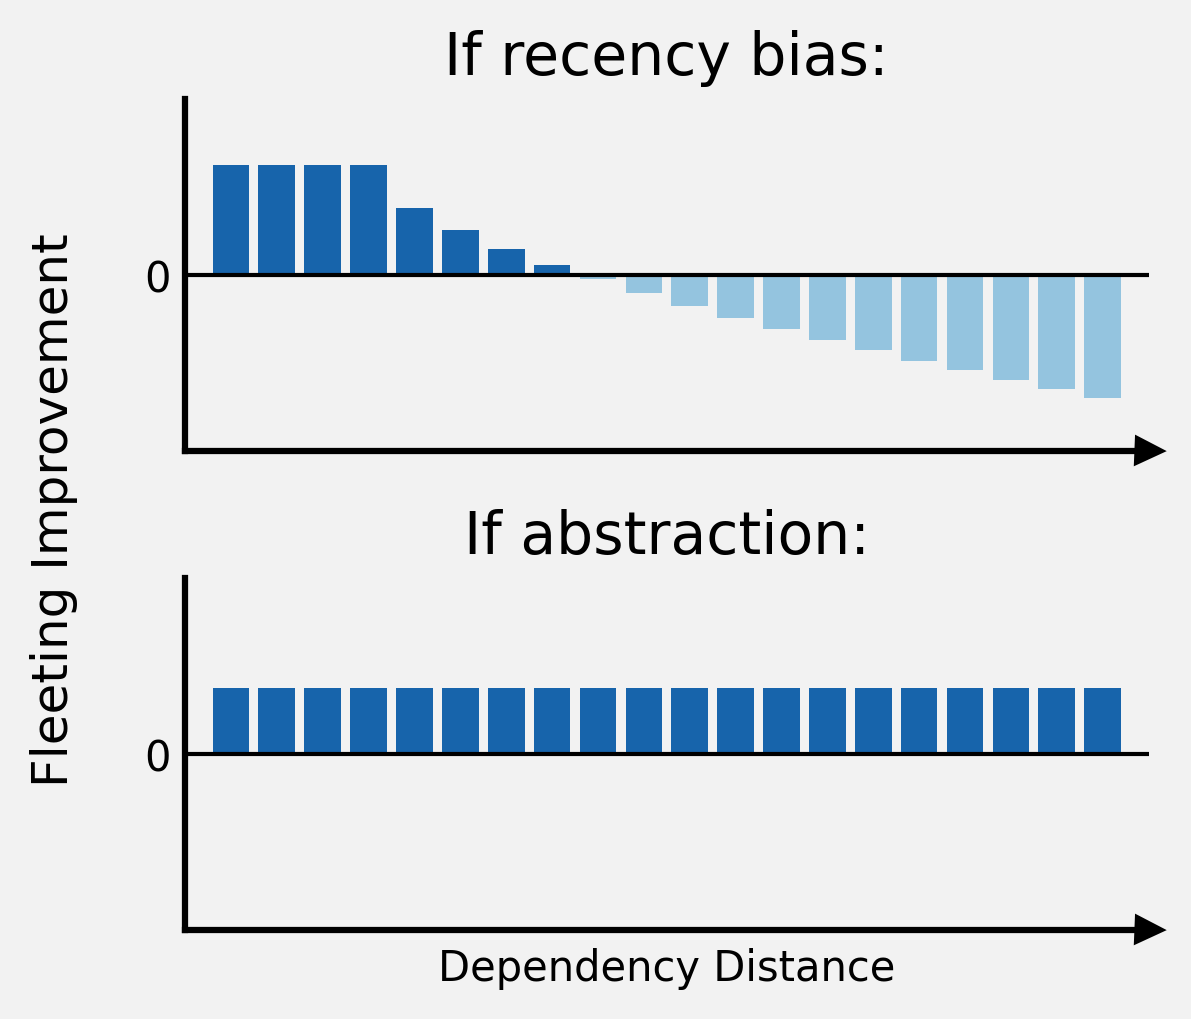

In [105]:
cmap = sns.color_palette("Blues", as_cmap=True)
mask_color = cmap(0.8)
nomask_color = cmap(0.4)

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(4, 3.5),
    sharex=True,
    sharey=True
)
bg_col = "#f2f2f2"
fig.patch.set_facecolor(bg_col)
ax1.set_facecolor(bg_col)
ax2.set_facecolor(bg_col)

x = np.arange(1, 21)

vals = np.array([decay_function(d, E=5, alpha=0.6, n=50)
                 for d in x]) - 0.75
cols = [mask_color if v > 0 else nomask_color for v in vals]
ax1.bar(x, vals, color=cols)
ax1.set_title("If recency bias:", fontsize=14)

vals_2 = np.array([decay_function(d, E=5, alpha=0.0000001, n=50)
                   for d in x]) - 0.85
cols_2 = [mask_color if v > 0 else nomask_color for v in vals_2]
ax2.bar(x, vals_2, color=cols_2)
ax2.set_title("If abstraction:", fontsize=14)
ax2.set_xlabel("Dependency Distance", fontsize=10)

axis_lw = 1.5

for ax in (ax1, ax2):
    ax.axhline(y=0, color="black", linewidth=1)

    ax.set_ylim(-0.4, 0.4)
    ax.set_xlim(0, 21)

    # ax.set_ylabel("Fleeting Improvement",
    #               fontweight="bold",
    #               fontsize=10)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.spines["bottom"].set_linewidth(axis_lw)
    ax.spines["left"].set_linewidth(axis_lw)

    ax.set_yticks([0])
    ax.set_xticks([])

    ax.tick_params(length=0)

    # Arrow at end of x-axis
    ax.plot(
        [ax.get_xlim()[1]],
        [-0.4],
        marker=">",
        markersize=6,
        color="black",
        clip_on=False
    )

fig.supylabel(
    "Fleeting Improvement",
    #fontweight="bold",
    fontsize=12,
    x=0.02  # adjust horizontal position if needed
)

plt.tight_layout()
plt.show()

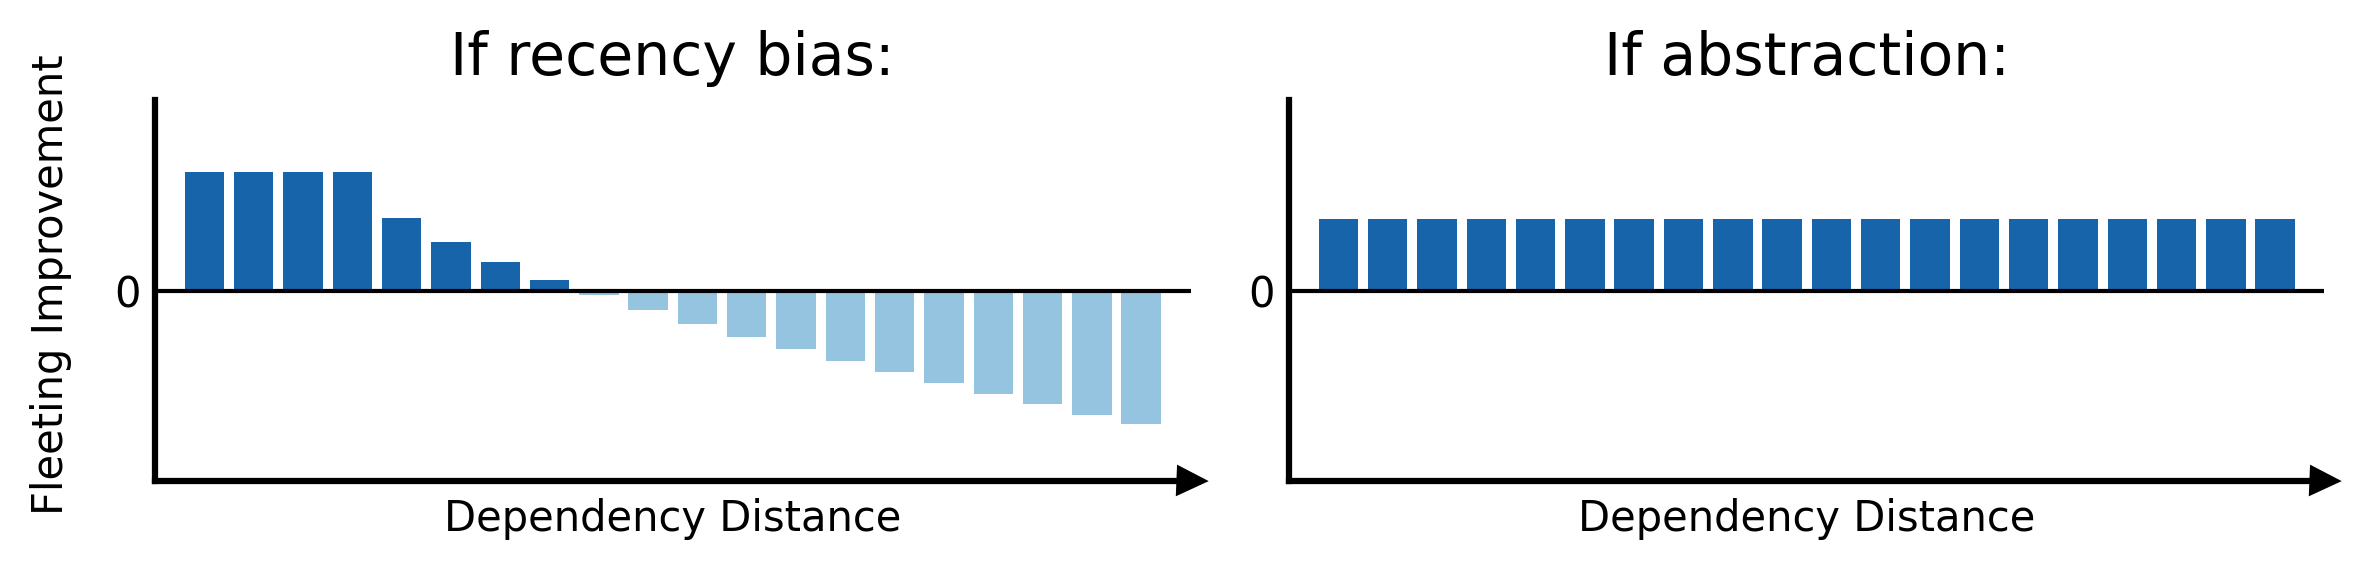

In [80]:
cmap = sns.color_palette("Blues", as_cmap=True)
mask_color = cmap(0.8)
nomask_color = cmap(0.4)

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(8, 2),
    # sharex=True,
    # sharey=True
)

x = np.arange(1, 21)

vals = np.array([decay_function(d, E=5, alpha=0.6, n=50)
                 for d in x]) - 0.75
cols = [mask_color if v > 0 else nomask_color for v in vals]
ax1.bar(x, vals, color=cols)
ax1.set_title("If recency bias:", fontsize=14)

vals_2 = np.array([decay_function(d, E=5, alpha=0.0000001, n=50)
                   for d in x]) - 0.85
cols_2 = [mask_color if v > 0 else nomask_color for v in vals_2]
ax2.bar(x, vals_2, color=cols_2)
ax2.set_title("If abstraction:", fontsize=14)
ax1.set_xlabel("Dependency Distance", fontsize=10)
ax2.set_xlabel("Dependency Distance", fontsize=10)

axis_lw = 1.5

for ax in (ax1, ax2):
    ax.axhline(y=0, color="black", linewidth=1)

    ax.set_ylim(-0.4, 0.4)
    ax.set_xlim(0, 21)

    # ax.set_ylabel("Fleeting Improvement",
    #               fontweight="bold",
    #               fontsize=10)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.spines["bottom"].set_linewidth(axis_lw)
    ax.spines["left"].set_linewidth(axis_lw)

    ax.set_yticks([0])
    ax.set_xticks([])

    ax.tick_params(length=0)

    # Arrow at end of x-axis
    ax.plot(
        [ax.get_xlim()[1]],
        [-0.4],
        marker=">",
        markersize=6,
        color="black",
        clip_on=False
    )

fig.supylabel(
    "Fleeting Improvement",
    #fontweight="bold",
    fontsize=10,
    x=0.02  # adjust horizontal position if needed
)
# fig.supxlabel(
#     "Dependency Distance",
#     #fontweight="bold",
#     fontsize=12,
#     #x=0.02  # adjust horizontal position if needed
# )

plt.tight_layout()
plt.show()

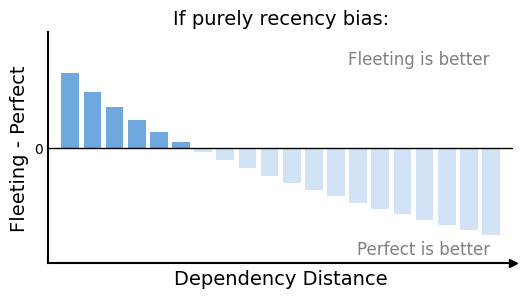

In [11]:
# ...existing code...
plt.figure(figsize=(6, 3))

values = np.array([decay_function(d, E = 0, alpha=1, n=50)  for d in range(1, 21)]) - 0.5

# Separate positive and negative bars
positive_mask = values >= 0
negative_mask = values < 0

# Plot positive bars (solid fill)
plt.bar(np.arange(1, 21)[positive_mask], values[positive_mask], color="#6FA8DC")

# Plot negative bars (hatched)
#plt.bar(np.arange(1, 21)[negative_mask], values[negative_mask], color="white", edgecolor="#6FA8DC", hatch='///', linewidth=1.5)
plt.bar(np.arange(1, 21)[negative_mask], values[negative_mask], color="#A4C8EA", alpha = 0.5)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.ylim([-0.3, 0.3])
plt.xlim([0, 21])

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.ylabel("Fleeting - Perfect", fontsize = 14)
plt.xlabel("Dependency Distance", fontsize = 14)
plt.title("If purely recency bias:", fontsize=14)

axis_lw = 1.5
ax = plt.gca()
ax.set_yticks([0])
ax.set_xticks([])

ax.text(0.95, 0.925, "Fleeting is better", transform=ax.transAxes, ha='right', va='top', 
        fontsize=12, color = "grey"
        )
ax.text(0.95, 0.1, "Perfect is better", transform=ax.transAxes, ha='right', va='top', 
        fontsize=12, color = "grey"
        )


ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.plot([ax.get_xlim()[1]], [-0.3], marker='>', markersize=6, color='black', clip_on=False)
ax.tick_params(length=0)

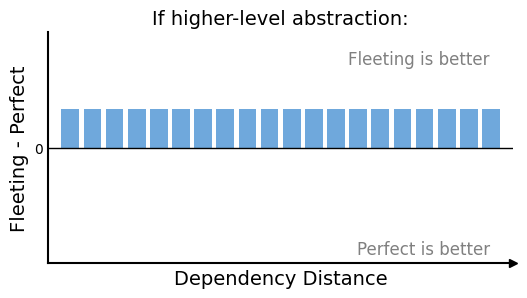

In [43]:
plt.figure(figsize=(6, 3))
plt.bar(np.arange(1, 21), np.repeat(0.1, 20), color="#6FA8DC")

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.ylim([-0.3, 0.3])
plt.xlim([0, 21])

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.ylabel("Fleeting - Perfect", fontsize = 14)
plt.xlabel("Dependency Distance", fontsize = 14)

axis_lw = 1.5
ax = plt.gca()
#ax.set_yticks([-1, 0, 1])
ax.set_yticks([0])
ax.set_xticks([])

ax.text(0.95, 0.925, "Fleeting is better", transform=ax.transAxes, ha='right', va='top', 
        fontsize=12, color = "grey"
        )
ax.text(0.95, 0.1, "Perfect is better", transform=ax.transAxes, ha='right', va='top', 
        fontsize=12, color = "grey"
        )
plt.title("If higher-level abstraction:", fontsize=14)

ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.plot([ax.get_xlim()[1]], [-0.3], marker='>', markersize=6, color='black', clip_on=False)
ax.tick_params(length=0)

/tmp/ipykernel_3097520/3159429308.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=12)


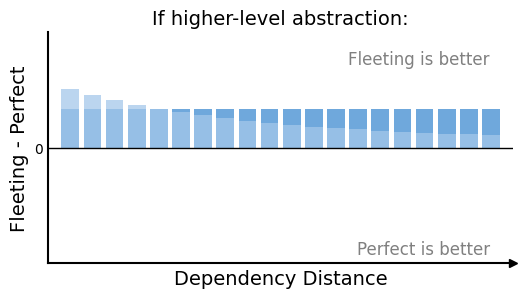

In [53]:
plt.figure(figsize=(6, 3))
plt.bar(np.arange(1, 21), np.repeat(0.1, 20), color="#6FA8DC", alpha=1)

# Overlay: decaying bars, lighter blue, always positive
decay = 0.15 * np.exp(-0.12 * np.arange(1, 21)) + 0.02  # always > 0
plt.bar(np.arange(1, 21), decay, color="#A4C8EA", alpha=0.75)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.ylim([-0.3, 0.3])
plt.xlim([0, 21])

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.ylabel("Fleeting - Perfect", fontsize=14)
plt.xlabel("Dependency Distance", fontsize=14)

axis_lw = 1.5
ax = plt.gca()
ax.set_yticks([0])
ax.set_xticks([])

ax.text(0.95, 0.925, "Fleeting is better", transform=ax.transAxes, ha='right', va='top', fontsize=12, color="grey")
ax.text(0.95, 0.1, "Perfect is better", transform=ax.transAxes, ha='right', va='top', fontsize=12, color="grey")
plt.title("If higher-level abstraction:", fontsize=14)

ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.plot([ax.get_xlim()[1]], [-0.3], marker='>', markersize=6, color='black', clip_on=False)
ax.tick_params(length=0)

plt.legend(frameon=False, fontsize=12)

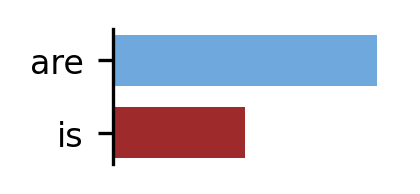

In [96]:
import matplotlib.pyplot as plt

sentence_tokens = ["is", "are"]
values = [0.4, 0.8]  # placeholder heights

colors = ["#9E2A2B", 
    "#6FA8DC"]

plt.figure(figsize=(1.5, 0.75))
plt.barh(sentence_tokens, values, color=colors, height=0.7)

ax = plt.gca()
# ax.set_xlabel("Probability", fontsize=16)
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=8)
# for label in ax.get_yticklabels():
#     label.set_weight("bold")
plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np

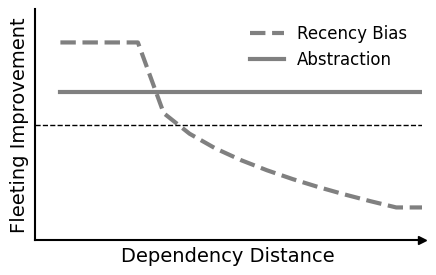

In [170]:

plt.figure(figsize=(5, 3))

def decay_function(d, E, alpha=0.5, n=10):
    if d < E:
        d = 1
    elif d >= E and d < n:
        exponent = 1 / (np.e * alpha)
        d =  1 - ((d-E+1)/(n-E))** exponent
    else:
        d = 0
    return d

n = 15

values = np.array([decay_function(d, E=5, alpha=1, n=n) for d in range(1, 21)]) - 0.5

# Separate positive and negative bars
positive_mask = values >= 0
negative_mask = values < 0

# Plot positive bars (solid fill)
plt.plot(np.arange(1, 21)[:n], values[:n], color = "grey", #color="#6FA8DC", 
         linewidth=3, linestyle="--", 
         label = "Recency Bias")
plt.plot(np.arange(1, 21)[:n], np.repeat(0.2, n), color="grey", 
         linewidth=3,
         label = "Abstraction")

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim([-0.7, 0.7])
plt.xlim([0, n])
plt.legend(loc="upper right", fontsize=12, frameon=False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.ylabel("Fleeting Improvement", fontsize = 14)
plt.xlabel("Dependency Distance", fontsize = 14)

axis_lw = 1.5
ax = plt.gca()
ax.set_yticks([])
ax.set_xticks([])


ax.spines["bottom"].set_linewidth(axis_lw)
ax.spines["left"].set_linewidth(axis_lw)
ax.plot([ax.get_xlim()[1]], [-0.7], marker='>', markersize=6, color='black', clip_on=False)
ax.tick_params(length=0)